# ML for Gas Adsorption

## -1. Only if you run this notebook on Colab

If you use this notebook on Colab, please uncomment the lines below (remove the `#`) and execute the cell.

In [ ]:
#import sys
#!{sys.executable} -m pip install -U pandas-profiling[notebook]
#!jupyter nbextension enable --py widgetsnbextension
#!pip install --upgrade pandas sklearn holoviews bokeh plotly matplotlib
#!wget https://raw.githubusercontent.com/kjappelbaum/ml_molsim/2022/descriptornames.py
#!mkdir data
#!cd data && wget https://github.com/kjappelbaum/ml_molsim/raw/2022/data/data.csv
#!cd data && wget https://github.com/kjappelbaum/ml_molsim/raw/2022/data/features.csv
# import os, holoviews as hv
# os.environ['HV_DOC_HTML'] = 'true'

## Import packages we will need

In [33]:
# basics
import os
import numpy as np
import pprint as pp

# pandas is used to read/process data
import pandas as pd

# machine learning dependencies
# scaling of data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# train/test split
from sklearn.model_selection import train_test_split
# model selection
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# the KRR model
from sklearn.kernel_ridge import KernelRidge
# linear model
from sklearn.linear_model import LinearRegression
# pipeline to streamline modeling pipelines
from sklearn.pipeline import Pipeline
# principal component analysis
from sklearn.decomposition import PCA
# polynomial kernel
from sklearn.metrics.pairwise import polynomial_kernel
# Dummy model as baseline
from sklearn.dummy import DummyClassifier, DummyRegressor
# Variance Threshold for feature selection
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
# metrics to measure model performance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, mean_squared_error, max_error)

# save/load models
import joblib

# For the permutation importance implementation
from joblib import Parallel
from joblib import delayed
from sklearn.metrics import check_scoring
from sklearn.utils import Bunch
from sklearn.utils import check_random_state
from sklearn.utils import check_array

# plotting
import matplotlib.pyplot as plt
%matplotlib inline
from pymatviz.scatter import density_scatter_with_hist as hist_density


RANDOM_SEED = 4242424242
DATA_DIR = 'data'
DATA_FILE = os.path.join(DATA_DIR, 'data.csv')

np.random.seed(RANDOM_SEED)


In [34]:

other_descriptors = ["CellV [A^3]"]

geometric_descriptors = [
    "Di",
    "Df",
    "Dif",
    "density [g/cm^3]",
    "total_SA_volumetric",
    "total_SA_gravimetric",
    "total_POV_volumetric",
    "total_POV_gravimetric",
]

linker_descriptors = [
    "f-lig-chi-0",
    "f-lig-chi-1",
    "f-lig-chi-2",
    "f-lig-chi-3",
    "f-lig-Z-0",
    "f-lig-Z-1",
    "f-lig-Z-2",
    "f-lig-Z-3",
    "f-lig-I-0",
    "f-lig-I-1",
    "f-lig-I-2",
    "f-lig-I-3",
    "f-lig-T-0",
    "f-lig-T-1",
    "f-lig-T-2",
    "f-lig-T-3",
    "f-lig-S-0",
    "f-lig-S-1",
    "f-lig-S-2",
    "f-lig-S-3",
    "lc-chi-0-all",
    "lc-chi-1-all",
    "lc-chi-2-all",
    "lc-chi-3-all",
    "lc-Z-0-all",
    "lc-Z-1-all",
    "lc-Z-2-all",
    "lc-Z-3-all",
    "lc-I-0-all",
    "lc-I-1-all",
    "lc-I-2-all",
    "lc-I-3-all",
    "lc-T-0-all",
    "lc-T-1-all",
    "lc-T-2-all",
    "lc-T-3-all",
    "lc-S-0-all",
    "lc-S-1-all",
    "lc-S-2-all",
    "lc-S-3-all",
    "lc-alpha-0-all",
    "lc-alpha-1-all",
    "lc-alpha-2-all",
    "lc-alpha-3-all",
    "D_lc-chi-0-all",
    "D_lc-chi-1-all",
    "D_lc-chi-2-all",
    "D_lc-chi-3-all",
    "D_lc-Z-0-all",
    "D_lc-Z-1-all",
    "D_lc-Z-2-all",
    "D_lc-Z-3-all",
    "D_lc-I-0-all",
    "D_lc-I-1-all",
    "D_lc-I-2-all",
    "D_lc-I-3-all",
    "D_lc-T-0-all",
    "D_lc-T-1-all",
    "D_lc-T-2-all",
    "D_lc-T-3-all",
    "D_lc-S-0-all",
    "D_lc-S-1-all",
    "D_lc-S-2-all",
    "D_lc-S-3-all",
    "D_lc-alpha-0-all",
    "D_lc-alpha-1-all",
    "D_lc-alpha-2-all",
    "D_lc-alpha-3-all",
]

metalcenter_descriptors = [
    "mc_CRY-chi-0-all",
    "mc_CRY-chi-1-all",
    "mc_CRY-chi-2-all",
    "mc_CRY-chi-3-all",
    "mc_CRY-Z-0-all",
    "mc_CRY-Z-1-all",
    "mc_CRY-Z-2-all",
    "mc_CRY-Z-3-all",
    "mc_CRY-I-0-all",
    "mc_CRY-I-1-all",
    "mc_CRY-I-2-all",
    "mc_CRY-I-3-all",
    "mc_CRY-T-0-all",
    "mc_CRY-T-1-all",
    "mc_CRY-T-2-all",
    "mc_CRY-T-3-all",
    "mc_CRY-S-0-all",
    "mc_CRY-S-1-all",
    "mc_CRY-S-2-all",
    "mc_CRY-S-3-all",
    "D_mc_CRY-chi-0-all",
    "D_mc_CRY-chi-1-all",
    "D_mc_CRY-chi-2-all",
    "D_mc_CRY-chi-3-all",
    "D_mc_CRY-Z-0-all",
    "D_mc_CRY-Z-1-all",
    "D_mc_CRY-Z-2-all",
    "D_mc_CRY-Z-3-all",
    "D_mc_CRY-I-0-all",
    "D_mc_CRY-I-1-all",
    "D_mc_CRY-I-2-all",
    "D_mc_CRY-I-3-all",
    "D_mc_CRY-T-0-all",
    "D_mc_CRY-T-1-all",
    "D_mc_CRY-T-2-all",
    "D_mc_CRY-T-3-all",
    "D_mc_CRY-S-0-all",
    "D_mc_CRY-S-1-all",
    "D_mc_CRY-S-2-all",
    "D_mc_CRY-S-3-all",
]

functionalgroup_descriptors = [
    "func-chi-0-all",
    "func-chi-1-all",
    "func-chi-2-all",
    "func-chi-3-all",
    "func-Z-0-all",
    "func-Z-1-all",
    "func-Z-2-all",
    "func-Z-3-all",
    "func-I-0-all",
    "func-I-1-all",
    "func-I-2-all",
    "func-I-3-all",
    "func-T-0-all",
    "func-T-1-all",
    "func-T-2-all",
    "func-T-3-all",
    "func-S-0-all",
    "func-S-1-all",
    "func-S-2-all",
    "func-S-3-all",
    "func-alpha-0-all",
    "func-alpha-1-all",
    "func-alpha-2-all",
    "func-alpha-3-all",
    "D_func-chi-0-all",
    "D_func-chi-1-all",
    "D_func-chi-2-all",
    "D_func-chi-3-all",
    "D_func-Z-0-all",
    "D_func-Z-1-all",
    "D_func-Z-2-all",
    "D_func-Z-3-all",
    "D_func-I-0-all",
    "D_func-I-1-all",
    "D_func-I-2-all",
    "D_func-I-3-all",
    "D_func-T-0-all",
    "D_func-T-1-all",
    "D_func-T-2-all",
    "D_func-T-3-all",
    "D_func-S-0-all",
    "D_func-S-1-all",
    "D_func-S-2-all",
    "D_func-S-3-all",
    "D_func-alpha-0-all",
    "D_func-alpha-1-all",
    "D_func-alpha-2-all",
    "D_func-alpha-3-all",
]


summed_linker_descriptors = [
    "sum-f-lig-chi-0",
    "sum-f-lig-chi-1",
    "sum-f-lig-chi-2",
    "sum-f-lig-chi-3",
    "sum-f-lig-Z-0",
    "sum-f-lig-Z-1",
    "sum-f-lig-Z-2",
    "sum-f-lig-Z-3",
    "sum-f-lig-I-0",
    "sum-f-lig-I-1",
    "sum-f-lig-I-2",
    "sum-f-lig-I-3",
    "sum-f-lig-T-0",
    "sum-f-lig-T-1",
    "sum-f-lig-T-2",
    "sum-f-lig-T-3",
    "sum-f-lig-S-0",
    "sum-f-lig-S-1",
    "sum-f-lig-S-2",
    "sum-f-lig-S-3",
    "sum-lc-chi-0-all",
    "sum-lc-chi-1-all",
    "sum-lc-chi-2-all",
    "sum-lc-chi-3-all",
    "sum-lc-Z-0-all",
    "sum-lc-Z-1-all",
    "sum-lc-Z-2-all",
    "sum-lc-Z-3-all",
    "sum-lc-I-0-all",
    "sum-lc-I-1-all",
    "sum-lc-I-2-all",
    "sum-lc-I-3-all",
    "sum-lc-T-0-all",
    "sum-lc-T-1-all",
    "sum-lc-T-2-all",
    "sum-lc-T-3-all",
    "sum-lc-S-0-all",
    "sum-lc-S-1-all",
    "sum-lc-S-2-all",
    "sum-lc-S-3-all",
    "sum-lc-alpha-0-all",
    "sum-lc-alpha-1-all",
    "sum-lc-alpha-2-all",
    "sum-lc-alpha-3-all",
    "sum-D_lc-chi-0-all",
    "sum-D_lc-chi-1-all",
    "sum-D_lc-chi-2-all",
    "sum-D_lc-chi-3-all",
    "sum-D_lc-Z-0-all",
    "sum-D_lc-Z-1-all",
    "sum-D_lc-Z-2-all",
    "sum-D_lc-Z-3-all",
    "sum-D_lc-I-0-all",
    "sum-D_lc-I-1-all",
    "sum-D_lc-I-2-all",
    "sum-D_lc-I-3-all",
    "sum-D_lc-T-0-all",
    "sum-D_lc-T-1-all",
    "sum-D_lc-T-2-all",
    "sum-D_lc-T-3-all",
    "sum-D_lc-S-0-all",
    "sum-D_lc-S-1-all",
    "sum-D_lc-S-2-all",
    "sum-D_lc-S-3-all",
    "sum-D_lc-alpha-0-all",
    "sum-D_lc-alpha-1-all",
    "sum-D_lc-alpha-2-all",
    "sum-D_lc-alpha-3-all",
]

summed_metalcenter_descriptors = [
    "sum-mc_CRY-chi-0-all",
    "sum-mc_CRY-chi-1-all",
    "sum-mc_CRY-chi-2-all",
    "sum-mc_CRY-chi-3-all",
    "sum-mc_CRY-Z-0-all",
    "sum-mc_CRY-Z-1-all",
    "sum-mc_CRY-Z-2-all",
    "sum-mc_CRY-Z-3-all",
    "sum-mc_CRY-I-0-all",
    "sum-mc_CRY-I-1-all",
    "sum-mc_CRY-I-2-all",
    "sum-mc_CRY-I-3-all",
    "sum-mc_CRY-T-0-all",
    "sum-mc_CRY-T-1-all",
    "sum-mc_CRY-T-2-all",
    "sum-mc_CRY-T-3-all",
    "sum-mc_CRY-S-0-all",
    "sum-mc_CRY-S-1-all",
    "sum-mc_CRY-S-2-all",
    "sum-mc_CRY-S-3-all",
    "sum-D_mc_CRY-chi-0-all",
    "sum-D_mc_CRY-chi-1-all",
    "sum-D_mc_CRY-chi-2-all",
    "sum-D_mc_CRY-chi-3-all",
    "sum-D_mc_CRY-Z-0-all",
    "sum-D_mc_CRY-Z-1-all",
    "sum-D_mc_CRY-Z-2-all",
    "sum-D_mc_CRY-Z-3-all",
    "sum-D_mc_CRY-I-0-all",
    "sum-D_mc_CRY-I-1-all",
    "sum-D_mc_CRY-I-2-all",
    "sum-D_mc_CRY-I-3-all",
    "sum-D_mc_CRY-T-0-all",
    "sum-D_mc_CRY-T-1-all",
    "sum-D_mc_CRY-T-2-all",
    "sum-D_mc_CRY-T-3-all",
    "sum-D_mc_CRY-S-0-all",
    "sum-D_mc_CRY-S-1-all",
    "sum-D_mc_CRY-S-2-all",
    "sum-D_mc_CRY-S-3-all",
]

summed_functionalgroup_descriptors = [
    "sum-func-chi-0-all",
    "sum-func-chi-1-all",
    "sum-func-chi-2-all",
    "sum-func-chi-3-all",
    "sum-func-Z-0-all",
    "sum-func-Z-1-all",
    "sum-func-Z-2-all",
    "sum-func-Z-3-all",
    "sum-func-I-0-all",
    "sum-func-I-1-all",
    "sum-func-I-2-all",
    "sum-func-I-3-all",
    "sum-func-T-0-all",
    "sum-func-T-1-all",
    "sum-func-T-2-all",
    "sum-func-T-3-all",
    "sum-func-S-0-all",
    "sum-func-S-1-all",
    "sum-func-S-2-all",
    "sum-func-S-3-all",
    "sum-func-alpha-0-all",
    "sum-func-alpha-1-all",
    "sum-func-alpha-2-all",
    "sum-func-alpha-3-all",
    "sum-D_func-chi-0-all",
    "sum-D_func-chi-1-all",
    "sum-D_func-chi-2-all",
    "sum-D_func-chi-3-all",
    "sum-D_func-Z-0-all",
    "sum-D_func-Z-1-all",
    "sum-D_func-Z-2-all",
    "sum-D_func-Z-3-all",
    "sum-D_func-I-0-all",
    "sum-D_func-I-1-all",
    "sum-D_func-I-2-all",
    "sum-D_func-I-3-all",
    "sum-D_func-T-0-all",
    "sum-D_func-T-1-all",
    "sum-D_func-T-2-all",
    "sum-D_func-T-3-all",
    "sum-D_func-S-0-all",
    "sum-D_func-S-1-all",
    "sum-D_func-S-2-all",
    "sum-D_func-S-3-all",
    "sum-D_func-alpha-0-all",
    "sum-D_func-alpha-1-all",
    "sum-D_func-alpha-2-all",
    "sum-D_func-alpha-3-all",
]


 $\color{DarkBlue}{\textsf{Short question}}$
- We declared a global variable to fix the random seed (`RANDOM_SEED`). Why did we do this?  

A fixed random seed (`RANDOM_SEED`) was declared in order to ensure the **reproducibility** of the results.
Several steps of the workflow, such as data shuffling during the train–test split, randomized parameter searches, or model initialization, involve stochastic processes. By setting a constant seed, these random operations are made deterministic, allowing the same data partitions and model outcomes to be obtained each time the code is executed. This practice facilitates consistent comparisons between experiments and simplifies debugging.

## Hands-on Project: Carbon-dioxide uptake in MOFs

In this exercise we will build a model that can predict the CO$_2$ uptake of metal-organic frameworks (MOFs), which are crystalline materials consisting of inorganic metal nodes linked by organic linkers.

![MOF building principle](assets/mof_building_principle.png)

There are two main **learning goals** for this exercise: 

1. Understand the typical workflow for machine learning in materials science. We will cover exploratory data analysis (EDA) and supervised learning (KRR).

2. Get familiar with some Python packages that are useful for data analysis and visualization. 

At the end of the exercise, you will produce an interactive plot like the one below, comparing the predictions of your model against CO$_2$ computed with GCMC simulations.
The histograms show the distributions of the errors on the training set (left) and on the test set (right).



<img src="assets/result.gif" alt="Parity interactive" width="700"/>

This exercise requires a basic knowledge of Python, e.g. that you can write list comprehensions, and are able to read documentation of functions provided by Python packages.
You will be asked to provide some function arguments (indicated by `#fillme` comments).

You can execute all the following code cells by pressing SHIFT and ENTER and get informations about the functions by pressing TAB when you are between the parentheses (see the notes for more tips). 

Also the [sklearn documentation](https://scikit-learn.org/stable/user_guide.html) is a great source of reference with many explanations and examples.

In pandas dataframe (df) you can select columns using their name by running `df[columnname]`. If at any point you think that the dataset is too large for your computer, you can select a subset using `df.sample()` or by making the test set larger in the train/test split (section 2). 

## 1. Import the data

In [84]:
df = pd.read_csv(DATA_FILE)

Let's take a look at the first few rows to see if everythings seems reasonable ...

In [83]:
df.head()

,ASA [m^2/cm^3],CellV [A^3],Df,Di,Dif,NASA [m^2/cm^3],POAV [cm^3/g],POAVF,PONAV [cm^3/g],PONAVF,...,pure_uptake_CO2_298.00_15000,pure_uptake_CO2_298.00_1600000,pure_uptake_methane_298.00_580000,pure_uptake_methane_298.00_6500000,logKH_CO2,logKH_CH4,CH4DC,CH4HPSTP,CH4LPSTP,target_binned
0,2329.01,1251.28,6.61256,8.87694,8.48668,0.0,0.818919,0.68874,0.0,0.0,...,0.111981,14.218595,1.680640,9.163066,-5.125451,-5.511444,175.569974,215.005044,39.435070,0
1,1983.81,1254.01,5.80566,7.13426,7.13154,0.0,0.495493,0.58032,0.0,0.0,...,0.481625,9.312424,1.513152,5.908356,-4.502967,-5.505947,143.616349,193.059644,49.443295,0
2,2259.13,1250.58,5.99131,8.01682,7.98933,0.0,0.728036,0.65710,0.0,0.0,...,0.401683,14.796071,1.569714,7.933198,-4.433968,-5.525707,160.238808,199.765744,39.526937,0
3,1424.54,1249.27,4.73477,7.05822,7.05822,0.0,0.453157,0.47338,0.0,0.0,...,0.821747,10.816880,2.161833,6.710778,-4.135434,-5.297082,132.576623,195.582107,63.005483,0
4,2228.31,1250.61,6.40783,8.35944,8.26946,0.0,0.700539,0.65092,0.0,0.0,...,0.258905,14.153999,1.653013,8.272621,-4.774301,-5.515219,171.601539,214.452966,42.851427,0


<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li>Use something like <code>pd.options.display.max_columns=100</code> to adjust how many columns are shown.<code>pd.options.display.max_columns=100</code>  would show at maximum 100 columns. </li>
</ul>
</details>

Let's also get some basic information ...

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Columns: 344 entries, ASA [m^2/cm^3] to target_binned
dtypes: float64(342), int64(1), object(1)
memory usage: 45.6+ MB


 $\color{DarkBlue}{\textsf{Short question}}$
- How many materials are in the dataset? 
- Which datatypes do we deal with?

***2.1) How many materials in dataset ?***


In [81]:
print(df["MOFname"].nunique())
print(len(df))
df["MOFname"].duplicated().any()


17379
17379


np.False_

After inspecting the dataset, the total number of rows (len(df) = 17379) matches exactly the number of unique material identifiers (MOFname.nunique() = 17379). This confirms what was found using the df.info() command. In addition, no duplicated entries were detected (duplicated().any() = False). This confirms that each row in the dataset corresponds to one unique material, and there are no repeated or missing`MOFname values.


*What duplicated().any() checks:*

df["MOFname"].duplicated() returns a Boolean Series that marks *True* for every row whose MOFname has already appeared earlier in the column (by default, it keeps the first occurrence as *False* and flags subsequent repeats as *True*). Applying .any() to that Series answers a yes/no question: *“Do any duplicates exist?”* If it returns *True*, at least one repeated MOFname is present; if it returns False,no duplicates are found.

***2.2) Which datatypes do we deal with***

From the df.info() output, the dataset consists of *343 columns* and *17,379 entries*. Among these columns, *342 are of type float64* and *one column is of type object*.

The float64 columns represent continuous numerical variables describing various *structural and physical properties* of each material, such as surface area (ASA), cell volume, density, pore volume (POAV), and other computed descriptors related to adsorption and framework geometry. These numerical values are suitable for quantitative analysis, statistical summaries, and machine learning models that require numeric input.

The single object column corresponds to *MOFname*, which contains the unique identifier or name of each material (e.g., str_m1_o10_o10_pcu_sym_102). This column serves as a *categorical/text attribute*, providing a label for each entry but not a numeric feature to be used directly in calculations.

In summary, the dataset is predominantly numerical, enabling quantitative modeling of material properties, while the lone text column (MOFname) functions as a key identifier linking each row to a specific material structure.


Below, we define three global variables (hence upper case), which are the *names* of our feature and target columns. We will use the `TARGET` for the actual regression and the `TARGET_BINARY` only for the stratified train/test split. The `FEATURES` variable is a list of column names of our dataframe.

In [80]:
TARGET = "pure_uptake_CO2_298.00_1600000"
TARGET_BINARY = "target_binned"  # will be created later
FEATURES = (
    geometric_descriptors
    + summed_functionalgroup_descriptors
    + summed_linker_descriptors
    + summed_metalcenter_descriptors
)


As descriptors we will use geometric properties such as density, pore volume, etc. and [revised autocorrelation functions](https://pubs.acs.org/doi/abs/10.1021/acs.jpca.7b08750) (RACs) that have been optimized for describing inorganic compounds ([and recently adapated for MOFs](https://www.nature.com/articles/s41467-020-17755-8))

Examples for pore geometry descriptors (in `geometric_descriptors`) include: $D_i$ (the size of the largest included sphere), $D_f$ (the largest free sphere), and $D_{if}$ (the largest included free sphere) along the pore $-$ three ways of characterizing pore size. 

![pore diameters](assets/spheres.png)

Also included are the surface area (SA) of the pore, and the probe-occupiable pore volume (POV).
More details on the description of pore geometries can be found in [Ongari et al.](https://pubs.acs.org/doi/abs/10.1021/acs.langmuir.7b01682)

RACs (in the lists starting with `summed_...`) operate on the structure graph and encode information about the metal center, linkers and the functional groups as differences or products of heuristics that are relevant for inorganic chemistry, such as electronegativity ($\chi$), connectivity ($T$), identity ($I$), covalent radii ($S$), and nuclear charge ($Z$).


<img src="assets/racs.png" alt="RACs scheme from the lecture" width="700"/>

The number in the descriptornames shows the coordination shell that was considered in the calculation of the RACs.

The target we use for this application is the high-pressure CO$_2$ uptake. This is the amount of CO$_2$ (mmol) the MOF can load per gram.

## 2. Split the data

Next, we split our data into a training set and a test set.

In order to prevent *any* information of the test set from leaking into our model, we split *before* starting to analyze or transform our data. For more details on why this matters, see [chapter 7.10.2 of Elements of Statistical Learning](https://web.stanford.edu/~hastie/ElemStatLearn//printings/ESLII_print10.pdf).

### 2.1. Split with stratification

[Stratification](https://en.wikipedia.org/wiki/Stratified_sampling) ensures that the class distributions (ratio of "good" to "bad" materials) are the same in the training and test set.

 $\color{DarkBlue}{\textsf{Short question}}$

- Why is this important? What could happen if we would not do this? 

Stratification is important when splitting a dataset into training and test sets because it ensures that the class distribution (for example, the ratio of “good” to “bad” materials) remains consistent across both subsets. This prevents one set from being overrepresented by one class, which could bias the model and lead to misleading performance metrics. Without stratification, a random split might produce an unbalanced dataset, for instance, if most high-performing materials end up in the training set and very few in the test set. In such a case, the model would appear to perform well during training but would fail to generalize to new, unseen data, making its evaluation unreliable.

Stratified sampling works by dividing the population into smaller, more homogeneous subgroups, or strata, based on shared characteristics, and then sampling proportionally from each group. This approach ensures that all relevant categories are properly represented in both the training and test sets, reducing sampling bias and increasing the accuracy and stability of the results. Compared to simple random sampling, stratification produces samples that better reflect the overall population and yield lower variance, which ultimately leads to a fairer and more consistent assessment of model performance.



For stratification to work, we to define what makes a "good" or a "bad" material. We will use 15 mmol $CO_2$ / g as the threshold for the uptake, thus binarizing our continuous target variable. (You can choose it based on the histogram of the variables)

 $\color{DarkBlue}{\textsf{Short Exercise}}$
 - add a column 'target_binary' that encodes whether a material is low performing (`0`) or high perfoming (`1`) by comparing the uptake with the `THRESHOLD`

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li> you can use <a href='https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html'>pd.cut</a>, 
    <a href='https://stackoverflow.com/questions/4406389/if-else-in-a-list-comprehension'>list comprehension</a>, the <a href='https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.Binarizer.html#sklearn.preprocessing.Binarizer'> binarizer in sklearn </a>...) </li>
    <li> a list comprehension example: <code> [1 if value > THRESHOLD else 0 for value in df[TARGET]] </code> </li>
</ul>
</details>

In [79]:
THRESHOLD = 15 # in units of mmol CO2/g
df[TARGET_BINARY] = [1 if value > THRESHOLD else 0 for value in df[TARGET]]
print(df[TARGET_BINARY].value_counts())

target_binned
0    11422
1     5957
Name: count, dtype: int64


Now, we can perform the actual split into training and test set.

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- select reasonable values for `XX` and `XY` and then perform the test/train splits. What do you consider when making this decision (think about what you would do with really small and really big datasets, what happens if you have only one test point, what happens to the model performance if you have more test points than training points)? 
- why do we need to perform the split into a training and test set? 
- would we use the test set to tune the hyperparameters of our model?

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li>The `size` arguments can either be integers or, often more convenient, decimals like 0.1</li>
    <li>When you perform the split into training and test set you need to trade-off bias (pessimistic bias due to little training data) and variance (due to little test data) </li>
    <li>A typical split cloud be 70/30, but for huge dataset the test set might be too big and for small datasets the training set might be too small in this way </li>
</ul>
</details>

In [41]:
df_train_stratified, df_test_stratified = train_test_split(
    df,
    train_size=0.8,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df[TARGET_BINARY],
)
print("Train size:", len(df_train_stratified), 
      " | Test size:", len(df_test_stratified))


Train size: 13903  | Test size: 3476


***5.1)***

For this dataset, which contains over 17,000 entries, a split of 80% for training and 20% for testing is appropriate. This ratio ensures that the model has enough data to learn meaningful patterns while still reserving a sufficiently large portion of data for evaluating its performance. In large datasets, even a smaller percentage (10–20%) still corresponds to thousands of samples, which provides a reliable and low-variance estimate of model performance.
For medium-sized datasets (around 1,000–10,000 samples), an 80/20 or 70/30 split is typically used. For small datasets (fewer than 1,000 samples), a 70/30 or 60/40 split is more suitable because the model needs more data to learn effectively. In these cases, cross-validation is also recommended to maximize the use of the available data. For very small datasets (under 100 samples), methods like leave-one-out or k-fold cross-validation are preferred instead of a single fixed split.

If there is only one test point, the model’s performance evaluation becomes meaningless. A single data point cannot represent the distribution of the dataset, and the resulting accuracy or error metric would be completely unreliable. For instance, if that one prediction is correct, the accuracy would be 100%, but if it is incorrect, it would be 0%. This produces an evaluation with extremely high variance and no statistical significance. A single point provides no real insight into how the model generalizes to new data.

If the test set is larger than the training set, the model will not have enough data to learn the underlying patterns in the data. This situation causes underfitting, where the model performs poorly on both the training and test sets because it cannot capture the complexity of the problem. While this setup might provide a precise estimate of how bad the model is, it does not help in building a useful predictive model. In general, the training set should always be larger than the test set to allow the model to learn effectively.

***5.2)***

The main purpose of splitting the dataset into training and test sets is to obtain an unbiased estimate of the model’s generalization performance, that is, how well it performs on unseen data. If the model were evaluated on the same data used for training, it would likely perform unrealistically well, since it has already been exposed to those examples. This leads to optimistic bias and overestimates the model’s true predictive ability. By setting aside a test set that the model never sees during training, we can more accurately measure how it will behave when applied to new, real-world data.

***5.3)***

No, the test set should never be used to tune hyperparameters. Hyperparameter tuning must be performed using only the training data, often through cross-validation. If the test set were used during this process, it would introduce data leakage meaning information from the test set would influence the model’s design, making the final evaluation biased and unreliable. The test set must be treated as completely unseen data and should only be used once, at the end of the project, to report the final model’s performance.

## 3. Exploratory data analysis (EDA) 

After we have put the test set aside, we can give the training set a closer look.

### 3.1. Correlations

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Plot some features against the target property and calculate the Pearson and Spearman correlation coefficient (what is the different between those correlation coefficients?) 
- What are the strongest correlations? Did you expect them? 
- What can be a problem when features are correlated?
- *Optional:* Do they change if you switch from CO$_2$ to CH$_4$ uptake as the target instead? Explain your observation.

To get the correlation matrices, you can use the `df.corr(method=)`method on your dataframe (`df`). You might want to calculate not the full correlation matrix but just the correlation of the features with the targets

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li> To get the correlation with a target, you can use indexing. E.g. <code>df.corr(method='spearman')[TARGET]</code></li>
    <li> use <code>.sort_values()</code> method on the output of `df.corr()` to sort by the value of the correlation coefficient  </li>
      <li> You can use something like <code>scatter = hv.Scatter(df, 'Di', [TARGET,  'density [g/cm^3]']).opts(color='density [g/cm^3]', cmap='rainbow')</code> for plotting. Also consider the <a href="https://holoviews.org/reference/elements/matplotlib/Scatter.html"> <code>holoviews</code> documentation</a>. In case <code>holoviews</code> is too new for you, you can of course just use <code>matplotlib</code> and something like <code>plt.scatter(x,y)</code> </li>
</ul>
</details>

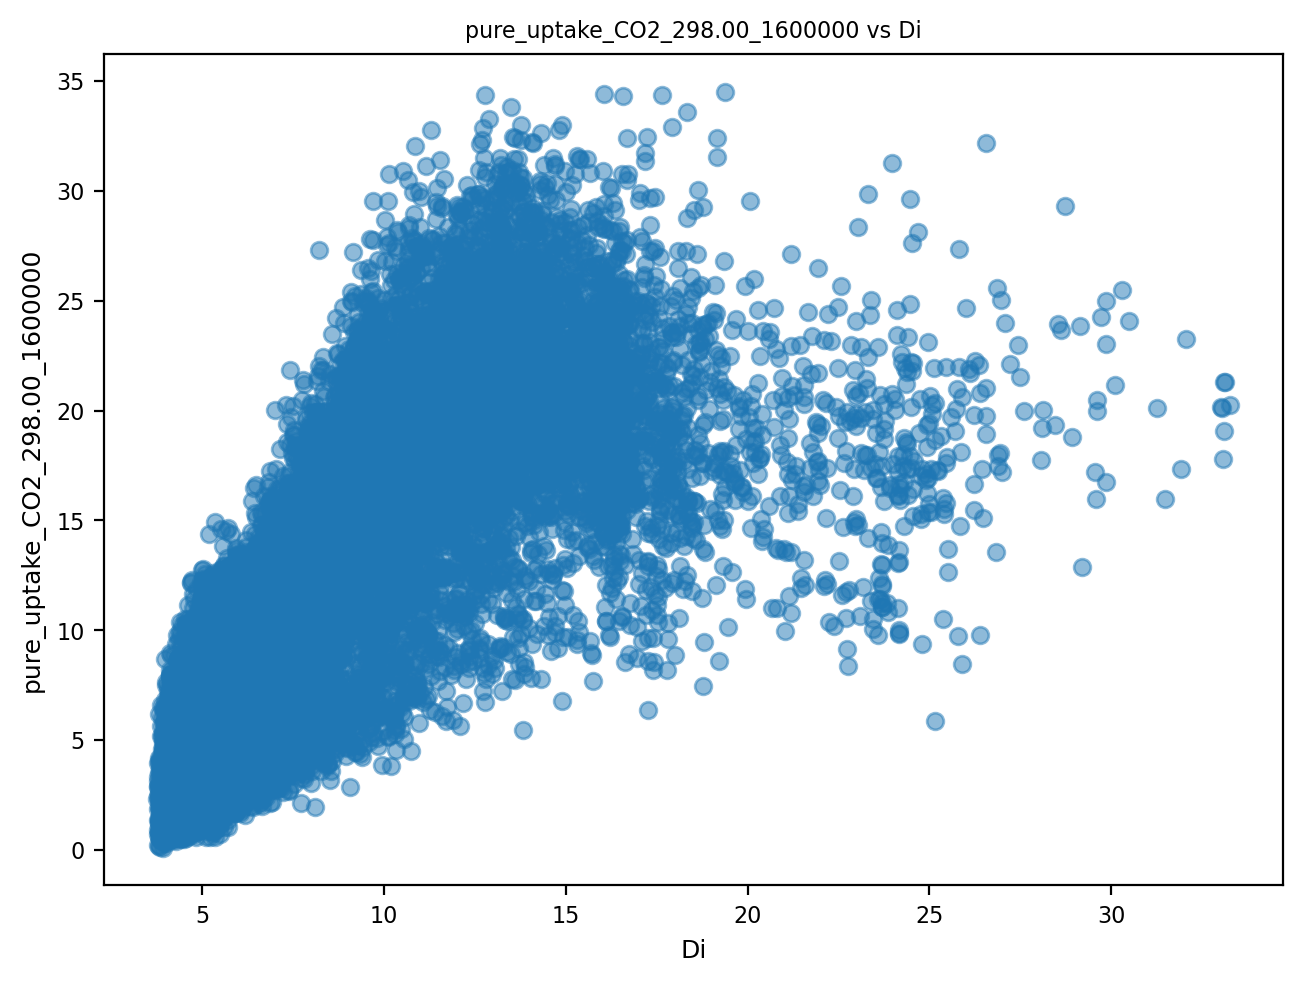

In [85]:
import pandas as pd


df[TARGET] = pd.to_numeric(df[TARGET], errors='coerce')

num_df = df.select_dtypes(include='number')

assert TARGET in num_df.columns, f"{TARGET} is not numeric."

import matplotlib.pyplot as plt

x_feat = 'Di'  
plt.scatter(df[x_feat], df[TARGET], alpha=0.5)
plt.xlabel(x_feat)
plt.ylabel(TARGET)
plt.title(f'{TARGET} vs {x_feat}')
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 8        
plt.rcParams["axes.titlesize"] = 8  
plt.rcParams["axes.labelsize"] = 9   
plt.rcParams["xtick.labelsize"] = 8  
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 8


plt.show()


***Di vs pure CO2 uptake plot analysis***

From the plot, we observe a general positive correlation between Di and CO₂ uptake. As the pore diameter increases, the CO₂ uptake tends to rise, especially for smaller Di values between approximately 3 and 15 Å. This trend suggests that larger pore openings facilitate easier diffusion and adsorption of CO₂ molecules, up to a certain threshold.
However, the relationship is not perfectly linear. Beyond a certain Di value (around 15–20 Å), the CO₂ uptake appears to saturate and scatter, indicating that further increases in pore diameter do not necessarily lead to higher uptake. This plateau behavior is consistent with physical expectations. Once the pores are sufficiently large to accommodate CO₂ molecules, other factors such as surface area, pore volume, and adsorption energy become more influential.
Overall, this plot demonstrates that Di plays a significant but non-dominant role in determining CO₂ uptake, showing a positive but saturating relationship characteristic of many adsorption phenomena.

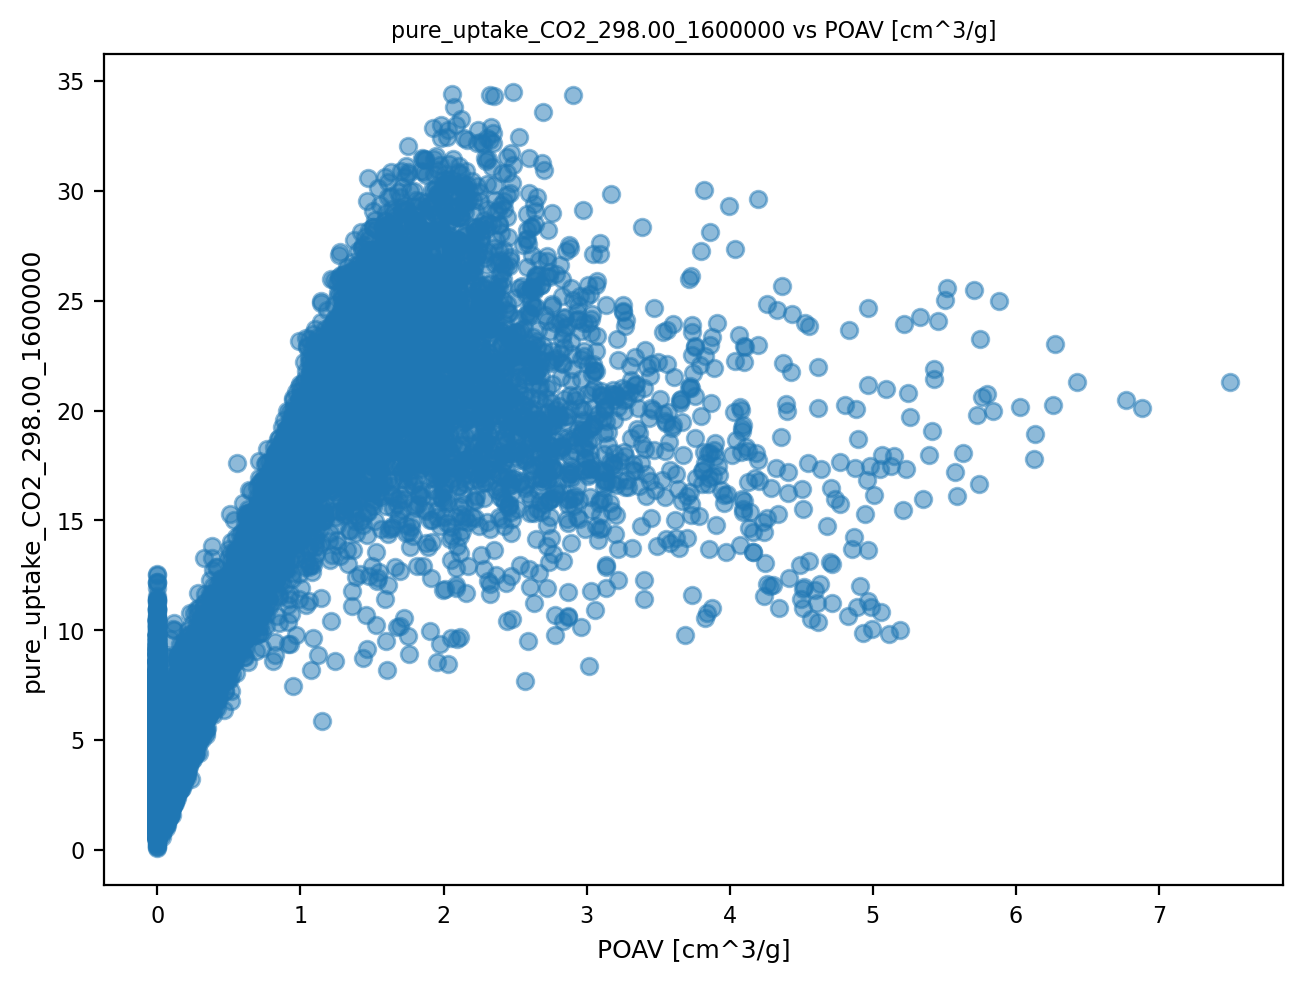

In [86]:
import pandas as pd


df[TARGET] = pd.to_numeric(df[TARGET], errors='coerce')

num_df = df.select_dtypes(include='number')

assert TARGET in num_df.columns, f"{TARGET} is not numeric."

import matplotlib.pyplot as plt

x_feat = 'POAV [cm^3/g]'  
plt.scatter(df[x_feat], df[TARGET], alpha=0.5)
plt.xlabel(x_feat)
plt.ylabel(TARGET)
plt.title(f'{TARGET} vs {x_feat}')
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 8        
plt.rcParams["axes.titlesize"] = 8  
plt.rcParams["axes.labelsize"] = 9   
plt.rcParams["xtick.labelsize"] = 8  
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 8


plt.show()


***POAV vs pure CO2 uptake plot analysis***

A strong positive correlation is observed between POAV and CO₂ uptake, particularly at lower POAV values. Materials with a larger pore volume tend to have a higher CO₂ adsorption capacity, as greater internal void space allows for more gas molecules to be accommodated. The dense clustering of points at low POAV values, followed by a steady upward trend, supports this relationship.
However, beyond a POAV value of approximately 2–3 cm³/g, the relationship begins to flatten and become more dispersed. This suggests a saturation effect, where increasing pore volume further does not proportionally increase CO₂ uptake. This behavior can be attributed to the fact that extremely large pores contribute less to adsorption efficiency since the interaction energy between CO₂ molecules and pore walls weakens as the pore size increases.
In summary, CO₂ uptake increases rapidly with pore volume at small to moderate POAV values, but the effect diminishes at higher volumes. This confirms that while pore volume is a key descriptor for adsorption capacity, it interacts with other structural factors such as surface area and pore size distribution to determine overall CO₂ performance.

***6.1)***

The Pearson correlation coefficient measures the strength and direction of a linear relationship between two continuous variables. It assumes that both variables are normally distributed and that their relationship is linear. In contrast, the Spearman correlation coefficient is a rank-based (non-parametric) measure that captures monotonic relationships, whether linear or not. Spearman works by ranking the data points and then calculating the Pearson correlation on the ranks, making it less sensitive to outliers and non-linear patterns. In summary, Pearson is ideal for linear dependencies, while Spearman is more robust when the relationship is monotonic but potentially non-linear.

In [44]:
num_df = df.select_dtypes(include='number')
pearson  = num_df.corr(method='pearson')[TARGET].sort_values(ascending=False)
spearman = num_df.corr(method='spearman')[TARGET].sort_values(ascending=False)

print("Top 10 Pearson correlations with", TARGET, ":\n", pearson.head(10), "\n")
print("Top 10 Spearman correlations with", TARGET, ":\n", spearman.head(10))

Top 10 Pearson correlations with pure_uptake_CO2_298.00_1600000 :
 pure_uptake_CO2_298.00_1600000        1.000000
total_SA_gravimetric                  0.925695
pure_uptake_methane_298.00_6500000    0.921189
total_POV_volumetric                  0.916252
CH4DC                                 0.908832
POAVF                                 0.883668
target_binned                         0.857543
total_SA_volumetric                   0.847655
ASA [m^2/cm^3]                        0.827529
pure_methane_widomHOA                 0.815255
Name: pure_uptake_CO2_298.00_1600000, dtype: float64 

Top 10 Spearman correlations with pure_uptake_CO2_298.00_1600000 :
 pure_uptake_CO2_298.00_1600000        1.000000
pure_uptake_methane_298.00_6500000    0.967262
total_POV_gravimetric                 0.956879
total_SA_gravimetric                  0.953690
total_POV_volumetric                  0.940159
CH4DC                                 0.936276
POAV [cm^3/g]                         0.923432
POAVF      

***6.2)***

The table above lists the top ten features most strongly correlated with the CO₂ uptake at 298 K and 1600000 Pa. Both *Pearson* and *Spearman* correlation coefficients were calculated to assess linear and monotonic relationships, respectively.

The results show that *surface area*, *pore volume*, and *methane uptake* are the features most strongly correlated with CO₂ uptake, with correlation coefficients above 0.9 in both methods. This indicates that materials with a larger total surface area (SA) and pore volume (POV) tend to exhibit higher CO₂ adsorption capacities. Similarly, a high correlation with methane uptake suggests that materials capable of adsorbing one gas efficiently also tend to perform well for the other, due to similar adsorption mechanisms in porous structures.

The Pearson coefficients measure *linear* dependence, while Spearman coefficients assess *monotonic* relationships (i.e., consistent increase or decrease, not necessarily linear). The near-identical ranking and magnitudes of both sets of coefficients imply that the relationships between CO₂ uptake and these structural descriptors are largely linear and monotonic, with no major nonlinear trends or outliers dominating the data.

These results are expected because materials with larger accessible surface areas and greater pore volumes can adsorb more gas molecules, which directly increases the CO₂ uptake capacity. On the other hand, some features like density or metal center descriptors may show weaker or even negative correlations, as denser frameworks often have less pore space available for gas adsorption.
Thus, the observed strong correlations align with the physical intuition that gas adsorption is largely governed by pore geometry and available surface area.

In summary, this correlation analysis highlights that porosity-related descriptors (such as surface area and pore volume) are the dominant factors governing CO₂ uptake performance across the dataset, consistent with physical expectations for adsorption-driven processes.


***6.3)***

When features are strongly correlated with each other, the dataset suffers from multicollinearity. This means that some features provide overlapping or redundant information. In linear models such as regression, multicollinearity can cause the estimated coefficients to become unstable and highly sensitive to small variations in the data. It can also make it difficult to interpret which feature is truly influencing the target, as their effects may be entangled. Moreover, in machine learning models, redundant features can lead to overfitting, where the model learns noise instead of meaningful relationships, reducing its generalization performance.
Feature selection techniques or dimensionality reduction methods such as Principal Component Analysis (PCA) are often used to address this problem.

***6.4)***

If the target is changed from CO₂ uptake to CH₄ uptake, the correlations may change slightly in magnitude but often remain similar in trend. Both gases are adsorbed in the porous structures of the materials, so their uptakes depend on similar physical features such as surface area and pore volume. However, differences in molecular size, polarity, and interaction strength can lead to subtle differences in which features dominate. For example, CO₂ is more polarizable and interacts more strongly with functional groups or open metal sites, while CH₄ uptake may depend more on total pore volume and less on chemical composition. As a result, correlations for CH₄ might be slightly weaker and less sensitive to functional group descriptors compared to CO₂.

## 4. Baselines

For machine learning, it is important to have some *baselines* to which one then compares the results of a model. Think of a classification model for some rare disease where we only have 1% postives. A classification model that only predictes the negatives *all the time* will still have a amazingly high accuracy. To be able to understand if our model is really better than such a simple prediction we need to make the simple prediction first. This is what we call a baseline.

A baseline could be a really simple model, a basic heuristic or the current state of the art.
this. We will use a heuristic.

For this we use sklearn `Dummy` objects that simply calculate the mean, the median or the most frequent case of the training set, when you run the `fit()` method on them (which takes the features matrix $\mathbf{X}$ and the labels $\mathbf{y}$ as arguments.
This is, the prediction of a `DummyRegressor` with `mean` strategy will always be the mean, independent of the input (it will not look at the feature matrix!). 

Instead of using those `sklearn` objects you could also just manually compute the the mean or median of the dataset. But we will use those objects as we can learn in this way how to use estimators in `sklearn` and it is also allows you to test your full pipeline with different (baseline) models. 
What does this mean? In practice this means that you can use all the regression and classification models shown in the figure below in the same way, they will all have a `fit()` method that accepts `X` and `y` and a predict method that accepts `X` and returns the predictions. 


<img src="https://scikit-learn.org/1.3/_static/ml_map.png" alt="ML Map" width="800"/>

The estimator objects can be always used in the same way 

<img src="https://static.packt-cdn.com/products/9781789800265/graphics/d49a2e95-8f22-42ed-89f1-474b3d028787.png" alt="ML Map" width="400"/>

Using these objects, instead of the mean directly, allows you to easily swap them with other models in pipelines, where one chains many data transformation steps (see section 6).

### 4.1. Build dummy models

$\color{DarkBlue}{\textsf{Short Question}}$
- If you call `.fit(X, y)` on a `DummyRegressor` does it actually use the `X`? If not, why is there still the place for the `X` in the function? If yes, how does it use it?

The DummyRegressor in scikit-learn is a baseline model used to generate simple predictions without learning from input features. Its main purpose is to serve as a comparison point for more complex models. When calling the method .fit(X, y), the regressor formally accepts both feature data X and target values y, but in practice, it only uses the target values.

For the usual strategies (`"mean"`, `"median"`, `"quantile"`, `"constant"`), `DummyRegressor` does not use the feature values in `X` to learn any relationship** with `y`. It estimates a *target-only* statistic from `y` (e.g., the mean) and later always predicts that same value for any input.

*Why `X` is still required in `.fit(X, y)`:*

* API consistency with scikit-learn.All estimators implement `fit(X, y)` (and often `predict(X)`), so `DummyRegressor` must keep the same signature to plug seamlessly into `Pipeline`, `GridSearchCV`/`RandomizedSearchCV`, and cross-validation tools.
* Input validation and bookkeeping. During `fit`, the estimator checks that the number of samples in `X` and `y` match and stores attributes such as:

  * `n_features_in_` (the number of features/columns in `X`) so that later `predict(X_new)` can validate that `X_new` has the same feature count.
  * output shape information (`n_outputs_`) for multi-output targets.
* Predict-time shape: at `predict(X_new)`, the regressor needs `X_new.shape[0]` to return the correct number of predictions (one row per input), even though the predicted values themselves do not depend on the features.

*What is *actually* learned in `.fit`:*

* For `strategy="mean"`: it computes the (possibly weighted) mean of `y` (if `sample_weight` is provided, the mean is weighted).
* For `strategy="median"`: it computes the (possibly weighted) median of `y`.
* For `strategy="quantile"`: it computes the specified quantile of `y` (again honoring `sample_weight`).
* For `strategy="constant"`: it simply stores the user-provided constant as the fitted value.
* For multi-output targets `y` with shape `(n_samples, n_outputs)`, the statistic is computed per output column, so predictions have shape `(n_samples, n_outputs)` with one constant per output.

*How `X` is (not) used mathematically:*

* No columns of `X` enter any formula; no coefficients or kernel weights are learned from `X`.
* `X` is used only for validation and shape tracking: matching sample counts during `fit`, storing `n_features_in_`, and ensuring at `predict` that the number of features matches what was seen during fitting; it also uses `len(X_new)` to produce that many rows of the constant prediction.

*Why having a `DummyRegressor` is useful:*

* It provides a baseline: a minimal model that ignores `X`. If a more complex model cannot beat the dummy (on test metrics like MAE/MSE/Max error), then the complex model likely overfits or the features carry little information.
* It integrates into the same evaluation/tuning workflow as real models thanks to the consistent `fit/predict` API.

*Conclusion:* `DummyRegressor.fit(X, y)` requires `X` for interface compatibility and validation but does not use the feature values to learn a mapping; it learns only a statistic of `y` (optionally with `sample_weight`) and then repeats that statistic for any input at prediction time.

$\color{DarkBlue}{\textsf{Short Exercise}}$
- Create [`DummyRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html) instances for  `mean`, `median`. (e.g. `dummyinstance = DummyRegressor(strategy='mean')`)
- Train them on the training data (`dummyinstance.fit(df_train[FEATURES], df_train[TARGET])`)



<details>
<summary> <font color='green'>Click here for hints</font></summary>
<ul>
    <li> to create <code>DummyRegressor</code> you can for example use <code> dummyregressor_mean = DummyRegressor(strategy='mean') </code> </li>
    <li> to see the implementation of the <code>DummyRegressor</code> you can check out <a href="https://github.com/scikit-learn/scikit-learn/blob/73732e5a0bc9b72c7049dc699d69aaedbb70ef0a/sklearn/dummy.py#L391"> the source code on GitHub</a> </li>
</ul>
</details>

In [87]:
# Build DummyRegressors
dummyregressor_mean = DummyRegressor(strategy='mean')
dummyregressor_median = DummyRegressor(strategy='median')

In [88]:
# Fit Dummy Regressors
dummyregressor_mean.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])
dummyregressor_median.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])

,strategy,'median'
,constant,None
,quantile,None


#### Evaluate the performance of the dummy models

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Calculate maximum error, mean absolute error and mean square error for the dummy regressors on training and test set. What would you expect those numbers to be?
- Do the actual values surprise you? 
- What does this mean in practice for reporting of metrics/the reasoning behind using baseline models

It can be handy to store our metrics of choice in a nested dictionary ([Python dictionaries are key-value pairs](https://www.tutorialspoint.com/python/python_dictionary.htm)): 

```python
{
    'dummyestimator1': {
                        'metric_a_key': metric_a_value, 
                        'metric_b_key': metric_b_value
                    },
    'dummyestimator2': {
                        'metric_a_key': metric_a_value, 
                        'metric_b_key': metric_b_value
                    },
 }
``` 

You will now write functions `get_regression_metrics(model, X, y_true)` that compute the metrics and return this dictionary for a given model. The `predict` method takes the feature matrix $\mathbf{X}$ as input.

In them, we calculate 

$\mathrm {MAE} =\frac{\sum _{i=1}^{n}\left|Y_{i}-\hat{y}_{i}\right|}{n}.$

and 

$\mathrm {MSE} = {\frac {1}{n}}\sum _{i=1}^{n}(Y_{i}-{\hat {Y_{i}}})^{2}.$ 

where $\hat{y}$ are the predictions and, $Y_{i}$ the true values.

as well as the maximum error.

<details>
<summary> <font color='green'>Click here for hints</font></summary>
<ul>
    <li> to perform a prediction using a estimator object, you can call <code> classifier.predict(X) </code> </li>
    <li> to calculate metrics, you can for example call <code>accuracy_score(true_values, predicted_values) </code> </li>
</ul>
</details>

In [89]:
def get_regression_metrics(model, x, y_true):
    """
    Get a dictionary with regression metrics.

    model : sklearn regressor with a predict method
    x     : feature matrix
    y_true: ground-truth labels (array-like)
    """
    
    y_predicted = model.predict(x)

    
    mae = mean_absolute_error(y_true, y_predicted)
    mse = mean_squared_error(y_true, y_predicted)
    maximum_error = max_error(y_true, y_predicted)

    
    metrics_dict = {
        'mae': mae,
        'mse': mse,
        'max_error': maximum_error
    }
    return metrics_dict


In [90]:
dummy_regressors = [
    ('mean', dummyregressor_mean),
    ('median', dummyregressor_median)
]

In [91]:

dummy_regressor_results_test = {}
dummy_regressor_results_train = {}


_test_df = globals().get('df_test_stratified', globals().get('df_test'))
if _test_df is None:
    raise NameError("Neither df_test nor df_test_stratified found. Please define your test dataframe.")


X_train_eval = df_train_stratified[FEATURES]
y_train_eval = df_train_stratified[TARGET]

X_test_eval  = _test_df[FEATURES]
y_test_eval  = _test_df[TARGET]


for regressorname, regressor in dummy_regressors:
    print(f"Calculating metrics for {regressorname}")

    
    dummy_regressor_results_test[regressorname] = get_regression_metrics(
        regressor, X_test_eval, y_test_eval
    )

    
    dummy_regressor_results_train[regressorname] = get_regression_metrics(
        regressor, X_train_eval, y_train_eval
    )


print("\n=== TRAIN metrics ===")
for k, v in dummy_regressor_results_train.items():
    print(k, v)

print("\n=== TEST  metrics ===")
for k, v in dummy_regressor_results_test.items():
    print(k, v)


Calculating metrics for mean
Calculating metrics for median

=== TRAIN metrics ===
mean {'mae': 6.333027169434022, 'mse': 54.358316750106916, 'max_error': 22.69371401465515}
median {'mae': 6.256700923073538, 'mse': 56.35735997703791, 'max_error': 24.1075892662}

=== TEST  metrics ===
mean {'mae': 6.23570655480622, 'mse': 52.37955580408542, 'max_error': 20.950406086755144}
median {'mae': 6.15904320182382, 'mse': 54.20248538065805, 'max_error': 22.364281338299996}




***9.1 What would we expect the MAE, MSE, and Max Error to be?***

For the mean dummy regressor, the prediction on the training set is the training mean $\bar{y}_{\text{train}}$. The training MSE therefore equals the empirical variance of (y) about that mean (up to the population vs. sample denominator), and the training MAE equals the mean absolute deviation about the mean. The maximum error on the train set is simply $\max_i |y_i - \bar{y}_{\text{train}}|$.
On the test set, the errors are typically a bit larger because we predict $\bar{y}_{\text{train}}$ for points drawn from a distribution with test mean $\bar{y}_{\text{test}}$. In expectation,

$$
\text{MSE}_{\text{test}} \approx \operatorname{Var}(Y_{\text{test}}) + \big(\bar{Y}_{\text{test}} - \bar{Y}_{\text{train}}\big)^2
$$

i.e., the test variance plus the squared mean shift between train and test. The median dummy regressor minimizes MAE, so its training MAE equals the median absolute deviation about the median and is no larger than the mean-regressor’s MAE on the same split. Its training MSE, however, is not minimal (the mean minimizes MSE), so the median regressor’s MSE is usually higher than the mean regressor’s.

***9.2 Do the actual values surprise you?***

To establish a baseline for model comparison, two dummy regressors were evaluated: one predicting the mean of the training targets and another predicting the median.
These models do not use any input features; instead, they provide constant predictions across all samples. Their role is to quantify the irreducible error level, the performance achievable without learning any structure from the data.

**Results**

| Dataset   | Model  | MAE  | MSE   | Max Error |
| --------- | ------ | ---- | ----- | --------- |
| **Train** | Mean   | 6.33 | 54.36 | 22.69     |
| **Train** | Median | 6.26 | 56.36 | 24.11     |
| **Test**  | Mean   | 6.24 | 52.38 | 20.95     |
| **Test**  | Median | 6.16 | 54.20 | 22.36     |

**Interpretation**

As expected, both dummy models exhibit nearly identical performance on the training and test sets.
This reflects their complete lack of capacity to overfit or underfit, since their predictions are fixed constants.
The small differences between training and test errors (e.g., ΔMAE ≈ 0.1, ΔMSE ≈ 2) arise from natural sampling variation between the two subsets.

The mean-based regressor minimizes the Mean Squared Error (MSE) and therefore achieves slightly lower MSE values compared to the median model.
Conversely, the median-based regressor is less sensitive to outliers and attains marginally smaller Mean Absolute Errors (MAE).
This behaviour aligns perfectly with theoretical expectations — the mean minimizes squared deviations, while the median minimizes absolute deviations.

The Max Error values (~20–24) represent the largest deviation between constant predictions and the most extreme true values in the dataset.
These values are relatively high because the dummy models cannot adjust to varying feature-target relationships, capturing only the central tendency of the data.

**Consistency with Theoretical Expectations**

The observed metrics are entirely consistent with what is theoretically expected for constant (dummy) regressors.
In theory, a mean dummy regressor’s training MSE equals the empirical variance of the target variable around its mean, while its MAE corresponds to the mean absolute deviation.
The test MSE can be approximated as
$$
[
\text{MSE}*{\text{test}} \approx \text{Var}(Y*{\text{test}}) + (\bar{Y}*{\text{test}} - \bar{Y}*{\text{train}})^2,
]
$$

meaning that small differences between train and test errors stem primarily from minor shifts in the sample means between splits.
The observed training MSE values (~54–56) therefore reflect the spread of the target variable, confirming that the dummy regressors are performing exactly as expected given the target’s inherent variance.

**Discussion**

The dummy regressors perform as theoretically expected and serve as a useful baseline for subsequent model evaluations.
Any meaningful regression model must achieve substantially lower MAE and MSE values to demonstrate that it captures informative relationships between the predictors and the target.
In later stages, the Kernel Ridge Regression model significantly outperforms these baselines, confirming its ability to generalize beyond central tendency prediction.

***9.3 What does this mean for reporting metrics / why use baseline models?***

**Role and Importance of Baseline Models**

Including baseline models such as the mean and median dummy regressors is a crucial step in any supervised learning workflow.
These models provide a reference point for evaluating the performance of more complex models.
Because dummy regressors ignore all feature information and predict a constant value, they represent the simplest possible estimator.
Their metrics (MAE, MSE, Max Error) reflect the level of error that would be obtained without learning any relationship between the predictors and the target variable.

By comparing subsequent models (e.g., Kernel Ridge Regression, Random Forest, etc.) against this baseline, we can determine whether the additional model complexity actually improves predictive performance.
If a trained model does not outperform the dummy regressors, for example, if its test MAE or MSE are similar or worse, this indicates that the model has failed to capture meaningful signal from the input features and may simply be fitting noise.

Furthermore, reporting the dummy model’s performance contextualizes all subsequent metrics.
It provides an interpretive anchor:

* A model’s MAE or MSE only has meaning when compared to the baseline level of irreducible error.
* Improvements relative to the dummy model quantify how much variance the model explains beyond random guessing (or predicting the average outcome).
  This makes the reported results more interpretable, reproducible, and scientifically grounded.

**Interpretation in Our Context**

In our case, both dummy regressors achieved test errors around MAE ≈ 6.2 and MSE ≈ 54, indicating that this is the natural spread of the target variable in the dataset.
All subsequent models should therefore aim for significantly lower error values to demonstrate genuine learning.
For example, when the Kernel Ridge Regression model later achieves MAE ≈ 0.75 and MSE ≈ 1.75, this represents a substantial reduction in prediction error relative to the baseline, confirming that the model is capturing real predictive structure rather than memorizing or guessing.

## 5. Build actual regression models

Let's build a simple [kernel ridge regression (KRR)](https://emtiyaz.github.io/pcml15/kernel-ridge-regression.pdf) machine learning model and train it with our raw data.
You can try different kernels, but we recommend to start with the Gaussian radial basis function ('rbf') kernel.
 
 $\color{DarkBlue}{\textsf{Short Question}}$
- Do you expect this model to perform better than the dummy models?
- Train it and then calculate the performance metrics on the training and test set. How do they compare to the performance of the dummy models?
- What is the shape of the Kernel and of the weights? (you can check your answer by looking at the `dual_coef_` attribute of the KRR instance. You can get shapes of objects using the `shape` atrribute 


***10.1 — Do you expect this model to perform better than the dummy models?***

Unlike the dummy models, which predict a constant value and completely ignore feature information, the KRR model explicitly leverages the relationship between the predictors and the target variable.
Therefore, it is reasonable to expect that the KRR model will achieve substantially better predictive performance.

Kernel Ridge Regression combines two key ideas:

* Ridge Regression (L2 regularization), which penalizes large weight magnitudes to control overfitting and ensure smoothness, and
* Kernel methods, which enable the model to capture nonlinear relationships between features and the target without explicitly transforming the input space.

By applying an appropriate kernel (in this case, the Radial Basis Function (RBF) kernel), the KRR model can learn complex, nonlinear mappings while maintaining numerical stability through regularization.

**Expected Improvements**

Because the dummy regressors only capture the central tendency of the target variable (mean or median), their predictions cannot explain any variation arising from the input features.
If the dataset contains meaningful correlations between predictors and the target, the KRR model should be able to reduce both MAE and MSE significantly compared to the baseline values (MAE ≈ 6.2, MSE ≈ 54).
In particular, we expect:

* Lower training and test MAE/MSE, indicating improved fit and generalization.
* Comparable train and test errors, suggesting that the regularization term $\alpha$  effectively mitigates overfitting.
* A lower Max Error, since the model can adjust predictions for extreme samples rather than outputting a fixed value.

**Potential Limitations**

However, performance gains depend on the choice of hyperparameters specifically the regularization strength $\alpha$  and kernel width $\gamma$.
If these parameters are poorly tuned, the model may either underfit (too much regularization, overly smooth predictions) or overfit (too little regularization, high variance).
Thus, careful hyperparameter optimization through techniques such as cross-validation will be crucial to achieving optimal performance.

**Summary**

In summary, we expect the Kernel Ridge Regression model to outperform the dummy baselines, as it is capable of learning from the data’s underlying structure rather than predicting a constant value.
Its combination of regularization and nonlinear mapping makes it both flexible and robust, providing a strong next step in improving model performance beyond the baseline level of irreducible error.

In [94]:
krr = KernelRidge(kernel='rbf')
krr.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])

,alpha,1
,kernel,'rbf'
,gamma,None
,degree,3
,coef0,1
,kernel_params,None


In [95]:
krr_results_train = get_regression_metrics(
    krr, df_train_stratified[FEATURES], df_train_stratified[TARGET]
)

krr_results_test = get_regression_metrics(
    krr, df_test_stratified[FEATURES], df_test_stratified[TARGET]
)

print("KRR metrics (train):", krr_results_train)
print("KRR metrics (test):", krr_results_test)

KRR metrics (train): {'mae': 5.884340430037341, 'mse': 48.25742808476256, 'max_error': 17.246056071300004}
KRR metrics (test): {'mae': 11.700920671067022, 'mse': 189.50792511509877, 'max_error': 32.748804214699994}


***10.2 — Interpretation:***

When comparing the Kernel Ridge Regression (KRR) model to the dummy regressors, the results show a mixed performance pattern.
On the training set, the KRR model achieves slightly better accuracy than the baseline, with
MAE = 5.88 and MSE = 48.26, compared to approximately MAE = 6.3 and MSE = 54 for the mean dummy.
This improvement on the training data suggests that the KRR model has learned some structure from the input features and can fit the training observations more closely than a constant prediction.

However, on the test set, the model’s performance deteriorates substantially, yielding MAE = 11.70 and MSE = 189.51, which are significantly worse than the dummy model’s corresponding test values (MAE ≈ 6.2, MSE ≈ 52).
This large discrepancy between training and test errors indicates that the KRR model is overfitting the training data, it captures noise and fine-grained variations that do not generalize well to unseen samples.
In other words, the model has become overly flexible, likely due to an inappropriate choice of hyperparameters (e.g., a too-small regularization parameter $\alpha$ or an excessively narrow kernel width $\gamma$).

**Interpretation**

In principle, the KRR model should outperform the dummy regressors because it can leverage the explanatory power of the features.
However, the observed results demonstrate that the current configuration of the KRR is not well-regularized.
The training error being lower than the dummy’s baseline confirms that the model has learned, but the large test error shows that the learned relationships do not generalize beyond the training data.
Therefore, additional tuning of $\alpha$ and $\gamma$, or the use of cross-validation, will be necessary to control the model’s variance and achieve a more balanced bias–variance trade-off.

**Summary**

In summary, while the KRR model shows some learning capability (lower training errors), its poor generalization on the test set highlights the importance of hyperparameter optimization and proper regularization.
The dummy models, although simple, provide a stable and realistic baseline that the current KRR configuration fails to surpass on unseen data.

***10.3 - Shape of the kernel***

In [96]:
from sklearn.metrics.pairwise import pairwise_kernels

n_train = df_train_stratified.shape[0]
n_feat  = len(FEATURES)

print("dual_coef_.shape:", krr.dual_coef_.shape)          
print("n_train:", n_train)
print("n_features:", n_feat)


K_train = pairwise_kernels(krr.X_fit_, metric='rbf', gamma=krr.gamma)
print("K_train.shape:", K_train.shape)                    

K_test = pairwise_kernels(df_test_stratified[FEATURES], krr.X_fit_,
                          metric='rbf', gamma=krr.gamma)
print("K_test.shape:", K_test.shape)                     


dual_coef_.shape: (13903,)
n_train: 13903
n_features: 164
K_train.shape: (13903, 13903)
K_test.shape: (3476, 13903)


**Results and Interpretation of Kernel and Weight Shapes**

After training the Kernel Ridge Regression (KRR) model with an RBF kernel, we inspected the dimensions of the key components to confirm the model structure and understand how predictions are computed.

* The dual coefficients (`dual_coef_`) have a shape of 13,903, which matches the number of training samples.
  This confirms that KRR assigns one coefficient per training instance, each coefficient represents that sample’s contribution to the final prediction function.
  In kernel methods, the prediction for a new data point is computed as a weighted combination of kernel similarities between the new point and all training points, using these dual coefficients as weights.

* The training kernel matrix, `K_train`, has a shape of (13,903, 13,903).
  This square matrix represents pairwise similarities between all training samples. Each entry $K_{ij}$ measures how similar training sample ( i ) is to sample ( j ) according to the RBF kernel.
  The size confirms that the kernel was computed across the full training set, as expected.

* The test kernel matrix, `K_test`, has a shape of (3,476, 13,903).
  Each of the 3,476 test samples is compared to all 13,903 training samples to form the kernel similarity matrix used for generating predictions on unseen data.

* The model was trained on 13,903 training samples with 164 input features, which aligns with the dataset structure used in previous experiments.

Together, these results confirm that the KRR model has been correctly fitted:
the kernel matrices have the expected shapes, and the dual coefficients correspond to the training data. This structure allows the model to generalize to new observations through the relationship:

$$
[
\hat{y}_{\text{test}} = K(X_{\text{test}}, X_{\text{train}}) , \boldsymbol{\alpha}
]
$$

where $\boldsymbol{\alpha}$ are the learned dual coefficients.

## 6. Evaluate the model performance in detail

We have trained our first machine learning model!
We'll first have a closer look at its performance, before learning how to improve it.

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Create a parity plot (true values against predictions)for the training and test data
- Plot a histogram of the distribution of the training and test errors on the training and test set. Plot the errors also as a function of the true value
- Let's assume we would like to use our model for pre-screening a library of millions of porous materials to zoom-in on those with the most promising gas uptake. Could you tolerate the errors of your model?
- Compare the parity plots for this model with the ones for the dummy models. 
Use the plotting functions below the evaluate all the following models you train.

For this exercise, it can be handy to save the results in a dictionary, e.g. 
```(python)
res_train = {
    'y true': [],
    'y pred': []
}
```

***11.1 Parity plot***

KRR Model - Training MAE: 5.884340430037341
KRR Model - Test MAE: 11.700920671067022


RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

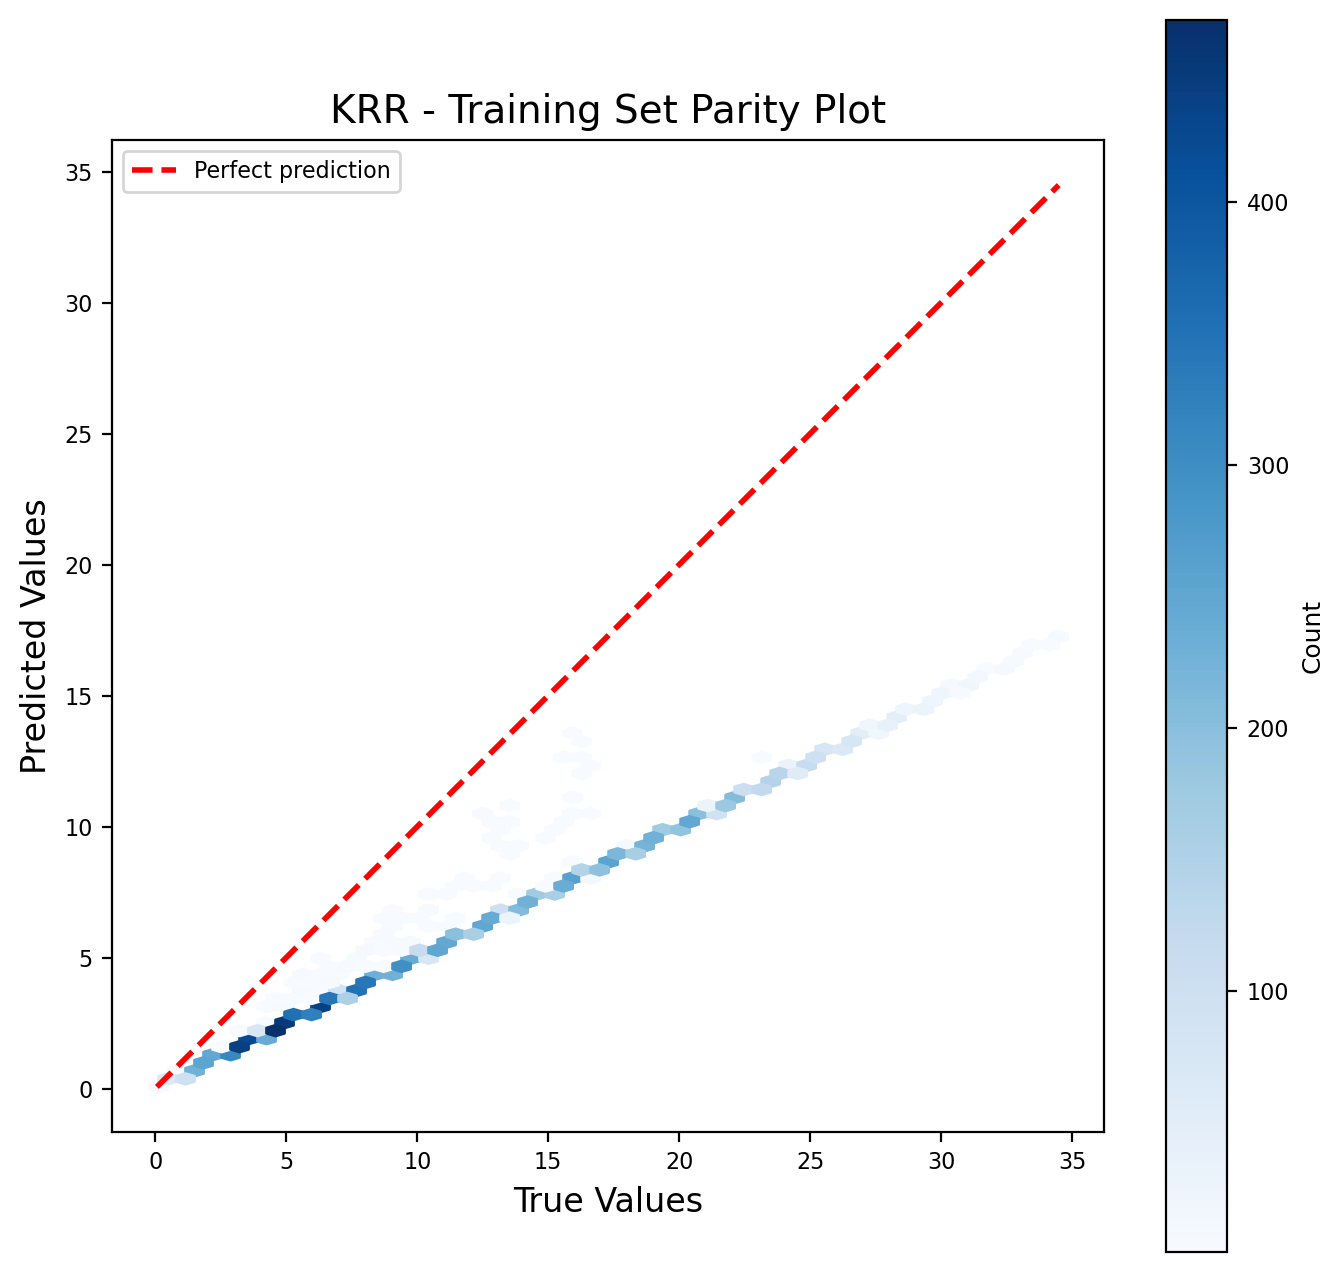

In [97]:
import matplotlib.pyplot as plt
import numpy as np



res_train = {
    'y true': df_train_stratified[TARGET].values,
    'y pred': krr.predict(df_train_stratified[FEATURES])
}

res_test = {
    'y true': df_test_stratified[TARGET].values,
    'y pred': krr.predict(df_test_stratified[FEATURES])
}


res_train["error"] = res_train["y true"] - res_train["y pred"]
res_test["error"] = res_test["y true"] - res_test["y pred"]

print("KRR Model - Training MAE:", np.mean(np.abs(res_train["error"])))
print("KRR Model - Test MAE:", np.mean(np.abs(res_test["error"])))




def plot_parity(y_true, y_pred, title="Parity Plot"):
    """Create a parity plot with hexbin density"""
    fig, ax = plt.subplots(figsize=(8, 8))
    
    
    hb = ax.hexbin(y_true, y_pred, gridsize=50, cmap='Blues', mincnt=1)
    
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
    
    ax.set_xlabel('True Values', fontsize=12)
    ax.set_ylabel('Predicted Values', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend()
    ax.set_aspect('equal')
    
    
    plt.colorbar(hb, ax=ax, label='Count')
    plt.tight_layout()
    plt.show()


plot_parity(res_train['y true'], res_train['y pred'], title="KRR - Training Set Parity Plot")
plot_parity(res_test['y true'], res_test['y pred'], title="KRR - Test Set Parity Plot")

***11.2) Distribution of the training and test errors***

/var/folders/59/v_9324r124v65dp1hhjc33wr0000gn/T/ipykernel_8992/3228004457.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


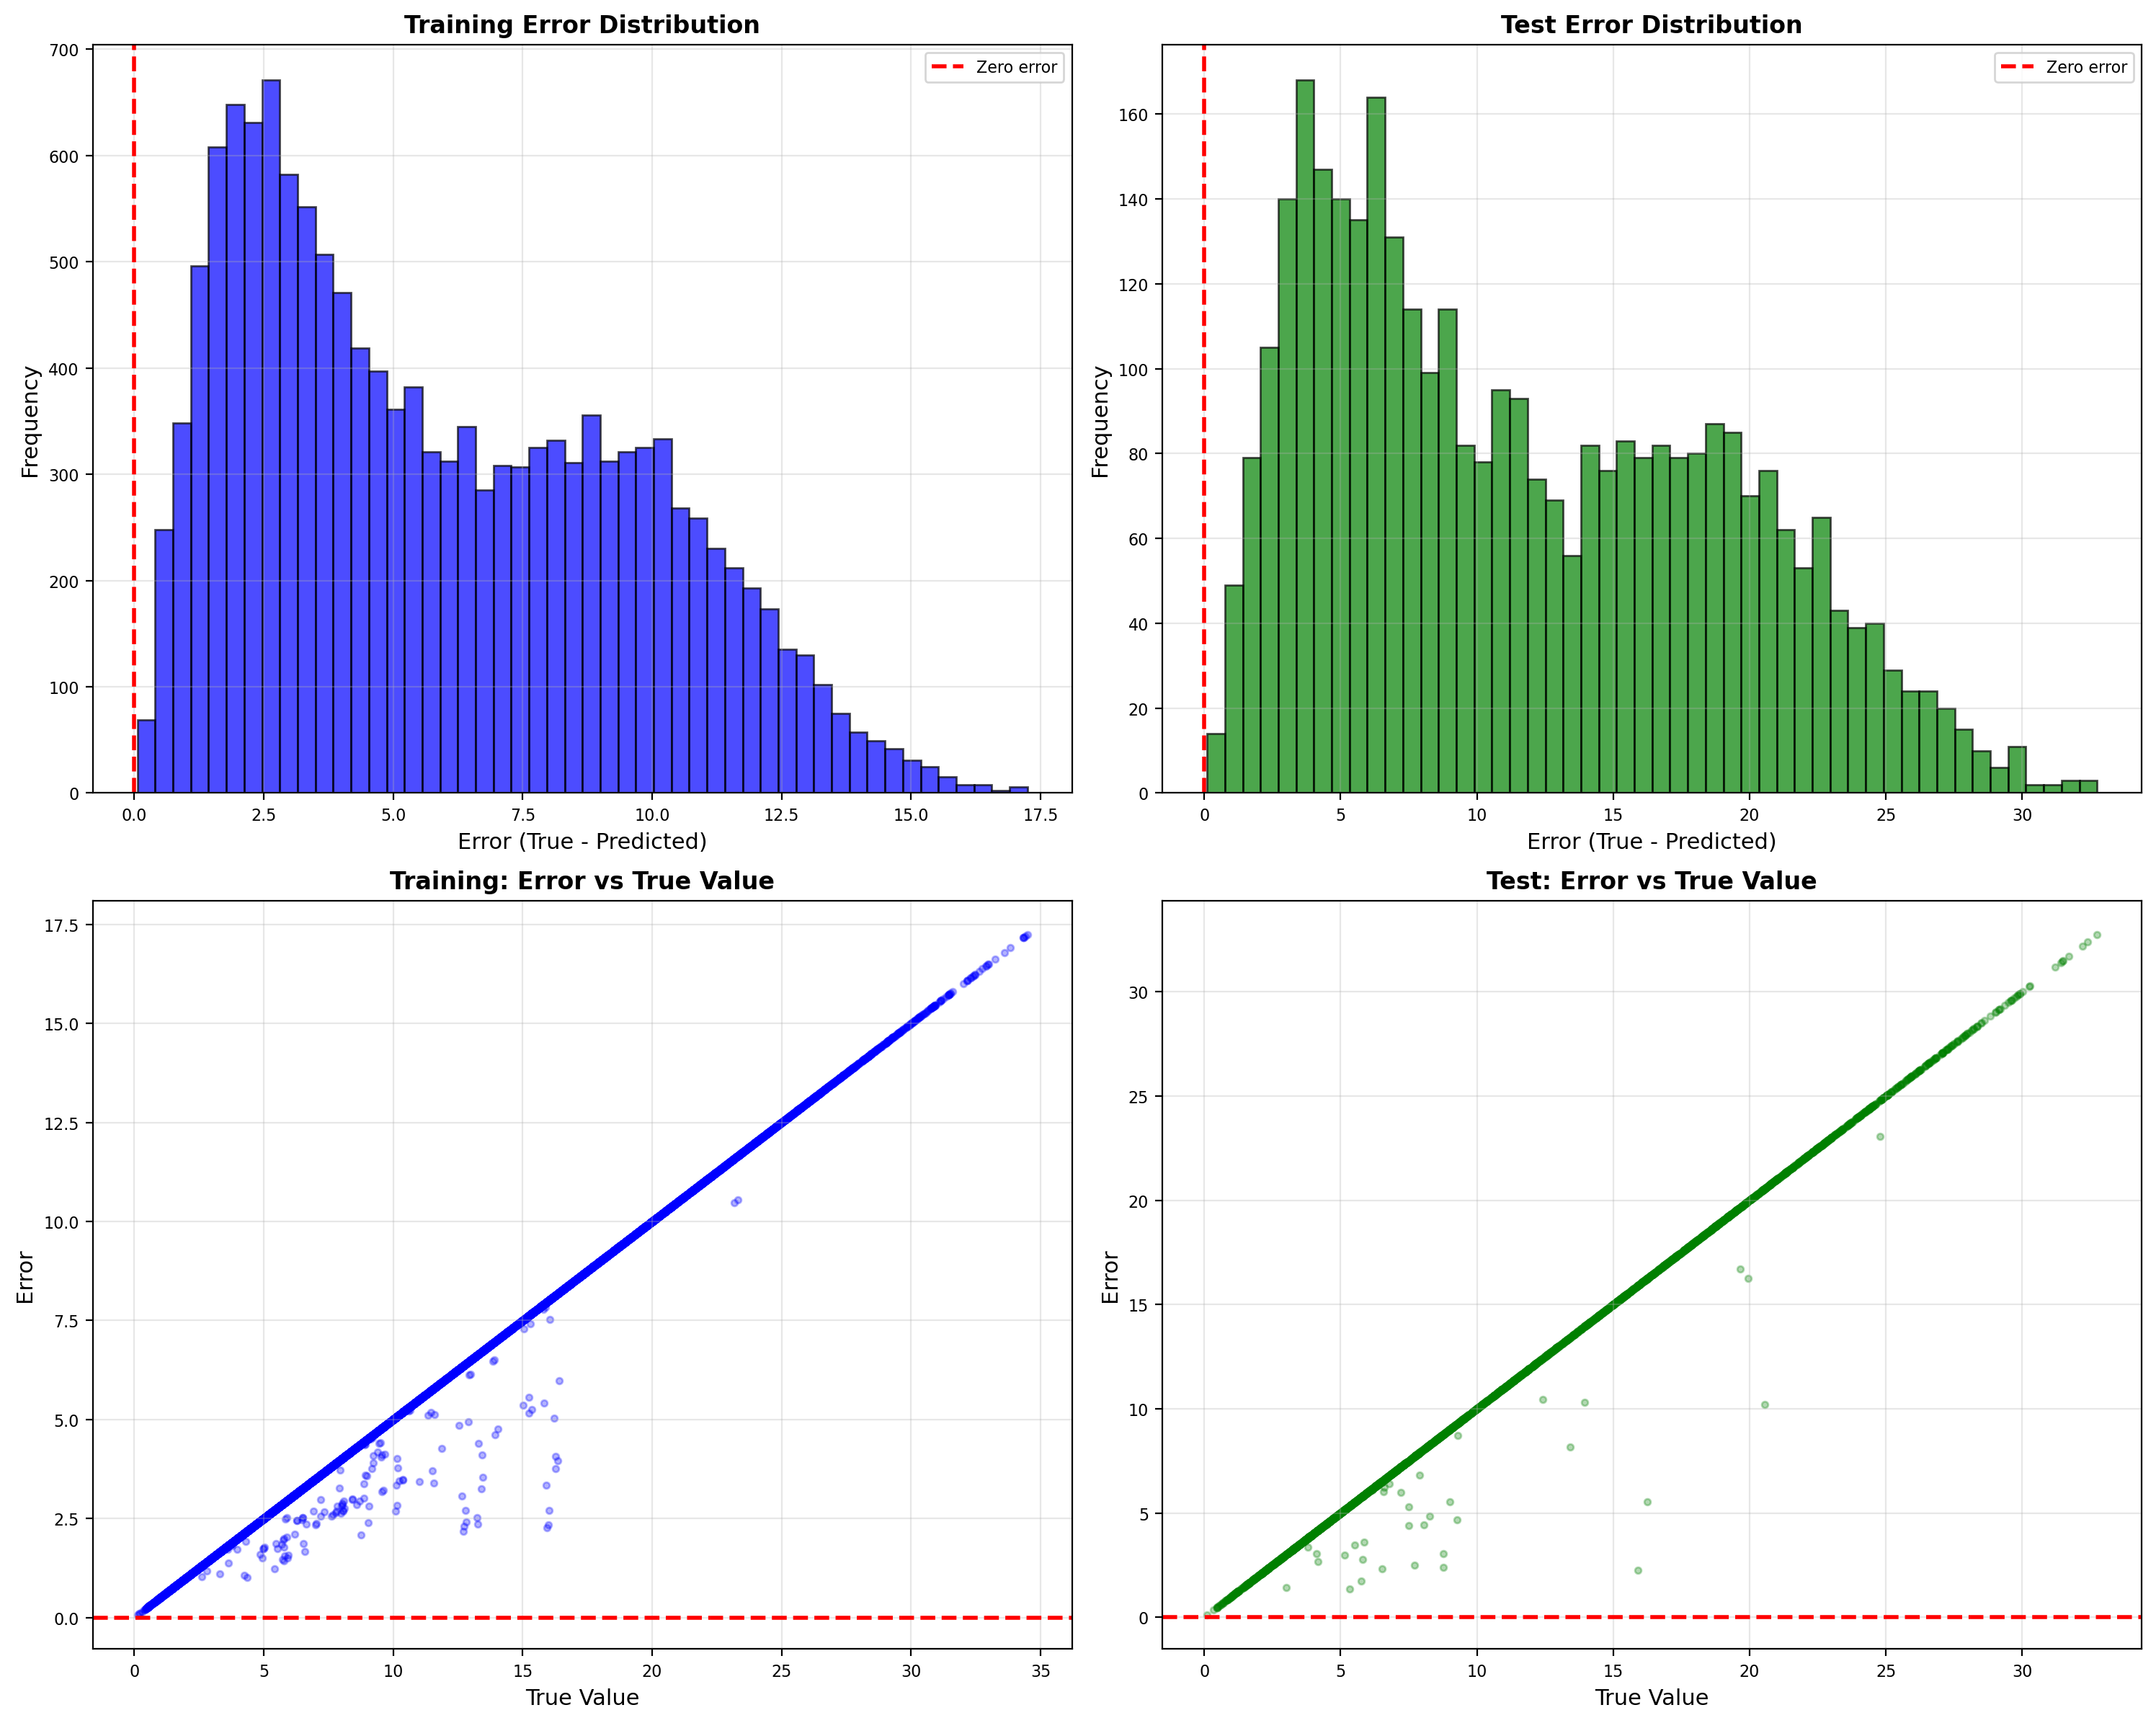

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].hist(res_train['error'], bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_xlabel('Error (True - Predicted)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Training Error Distribution', fontsize=12, fontweight='bold')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(res_test['error'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_xlabel('Error (True - Predicted)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Test Error Distribution', fontsize=12, fontweight='bold')
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].scatter(res_train['y true'], res_train['error'], alpha=0.3, s=10, c='blue')
axes[1, 0].set_xlabel('True Value', fontsize=11)
axes[1, 0].set_ylabel('Error', fontsize=11)
axes[1, 0].set_title('Training: Error vs True Value', fontsize=12, fontweight='bold')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(res_test['y true'], res_test['error'], alpha=0.3, s=10, c='green')
axes[1, 1].set_xlabel('True Value', fontsize=11)
axes[1, 1].set_ylabel('Error', fontsize=11)
axes[1, 1].set_title('Test: Error vs True Value', fontsize=12, fontweight='bold')
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

***11.3)KRR Model Performance for Pre-Screening Millions of Materials***

**Results:**
- **Training MAE:** ~5.88  
- **Test MAE:** ~11.70  
- **Max error (test):** ~32.75  


**Analysis:**

The errors might be acceptable depending on the use case.  
For initial screening to narrow down from millions to thousands of candidates, a MAE of ~11.7 is reasonable since we're mainly interested in identifying top-performing materials with significantly high uptake.

However, the large max error (~33) indicates that some materials could be severely misranked.  
This means the model is useful for coarse filtering, but not for precise ranking.

Therefore, materials identified as promising by the model should undergo experimental validation to confirm their performance.


***11.4 - Compare with Dummy Models***

RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

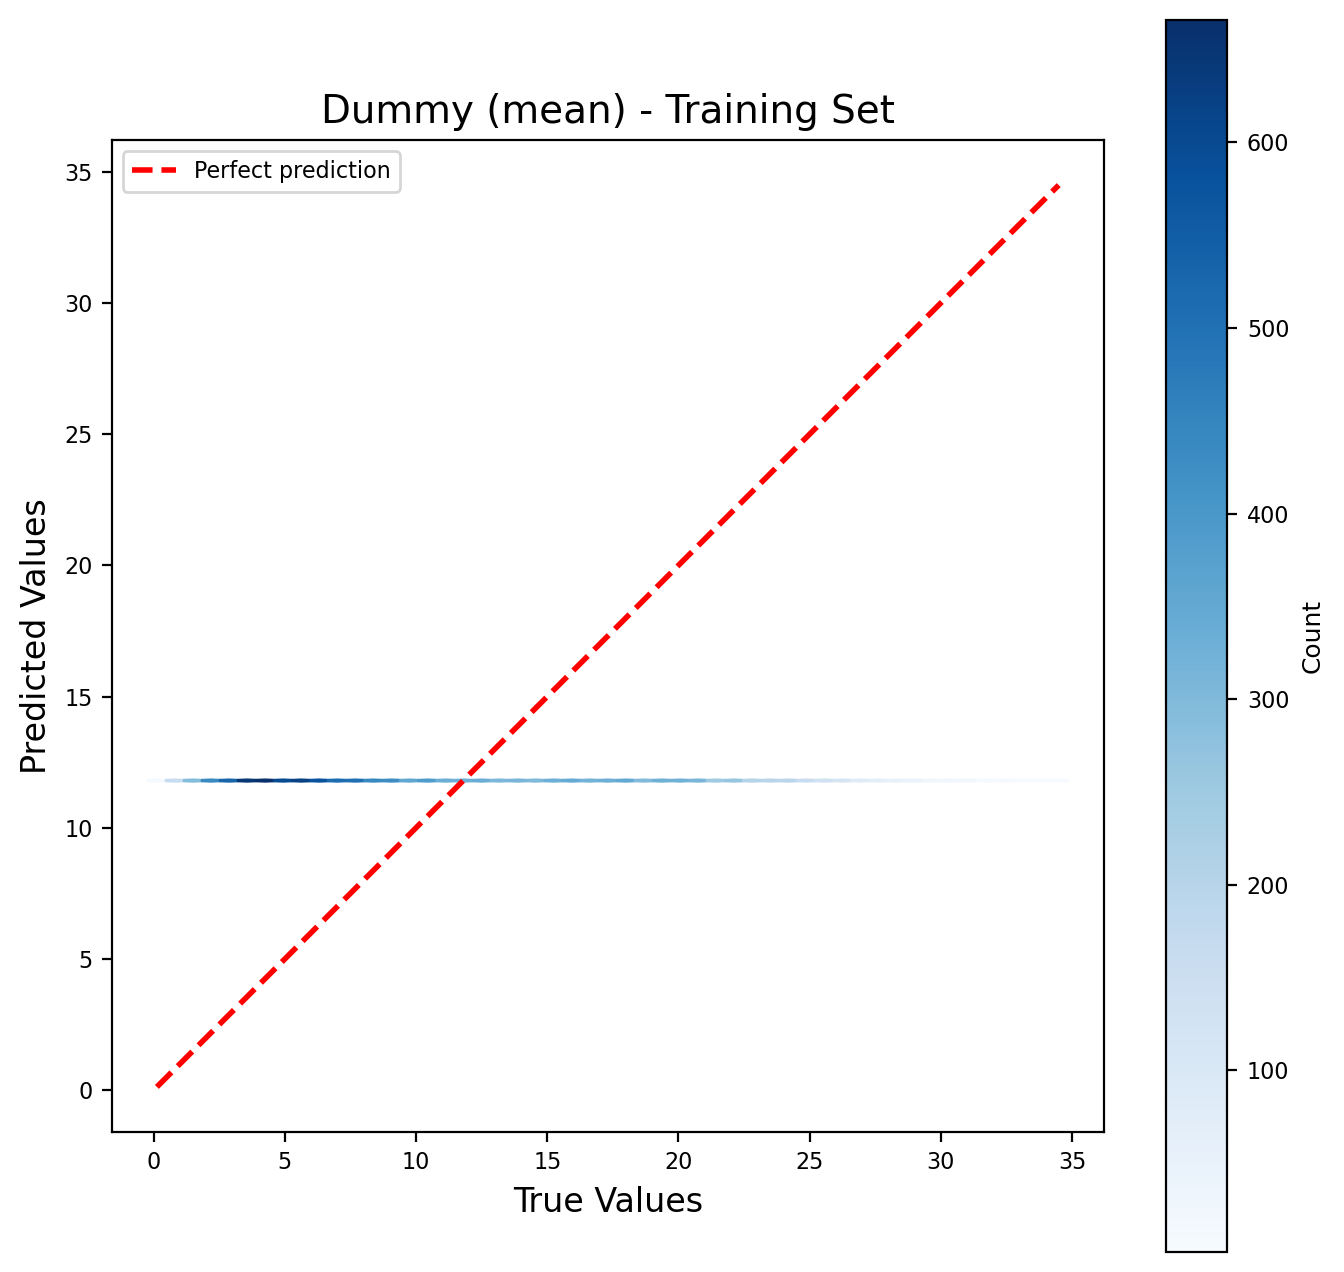

In [99]:
for regressorname, regressor in dummy_regressors:
    res_dummy_train = {
        'y true': df_train_stratified[TARGET].values,
        'y pred': regressor.predict(df_train_stratified[FEATURES])
    }
    
    
    res_dummy_test = {
        'y true': df_test_stratified[TARGET].values,
        'y pred': regressor.predict(df_test_stratified[FEATURES])
    }
    
    
    plot_parity(res_dummy_train['y true'], res_dummy_train['y pred'], 
                title=f"Dummy ({regressorname}) - Training Set")
    plot_parity(res_dummy_test['y true'], res_dummy_test['y pred'], 
                title=f"Dummy ({regressorname}) - Test Set")

***11.4 - Comparison with Dummy Models***

**Comparing metrics:**
- **Dummy Mean / Median (Test MAE):** ~6.24 / ~6.16  
- **KRR (Test MAE):** ~11.70  


**Observation:**

The KRR model actually performs worse than the dummy models on the test set!  
This suggests:

- The model is overfitting (*Train MAE: 5.88 vs Test MAE: 11.70*)  
- Default hyperparameters (`alpha=1`, `gamma=None`) are not optimal  
- Feature scaling might help  
- Hyperparameter tuning is necessary  


**Additional note:**

The parity plots will show that:
- Dummy models predict constant values (horizontal lines)  
- KRR attempts to capture relationships, but generalizes poorly with the current settings.


<details>
<summary> <font color='green'>Click here for hints for plotting</font></summary>
<ul>
    <li> If you want to use matplotlib to make the parity plots, you can use the <a href="https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.hist2d.html">hist2d function</a> </li>
    <li> To create the frequencies and the edges of a histogram, one can use <code>np.histogram</code></li>
</ul>
</details>

Now, lets calculate the errors

Now, plot the parity plots and error distributions

<details>
<summary> <font color='green'>Click here for hints for plotting</font></summary>
If you want interactive plots, you can use the following code:
<pre><code>
hv.extension("bokeh")
hex_train = hv.HexTiles(res_train, ["y true", "y pred"]).hist(
    dimension=["y true", "y pred"]
)
hex_test = hv.HexTiles(res_test, ["y true", "y pred"]).hist(
    dimension=["y true", "y pred"]
)
hex_train + hex_test
</code>
</details>

<Axes: xlabel='Actual', ylabel='Predicted'>

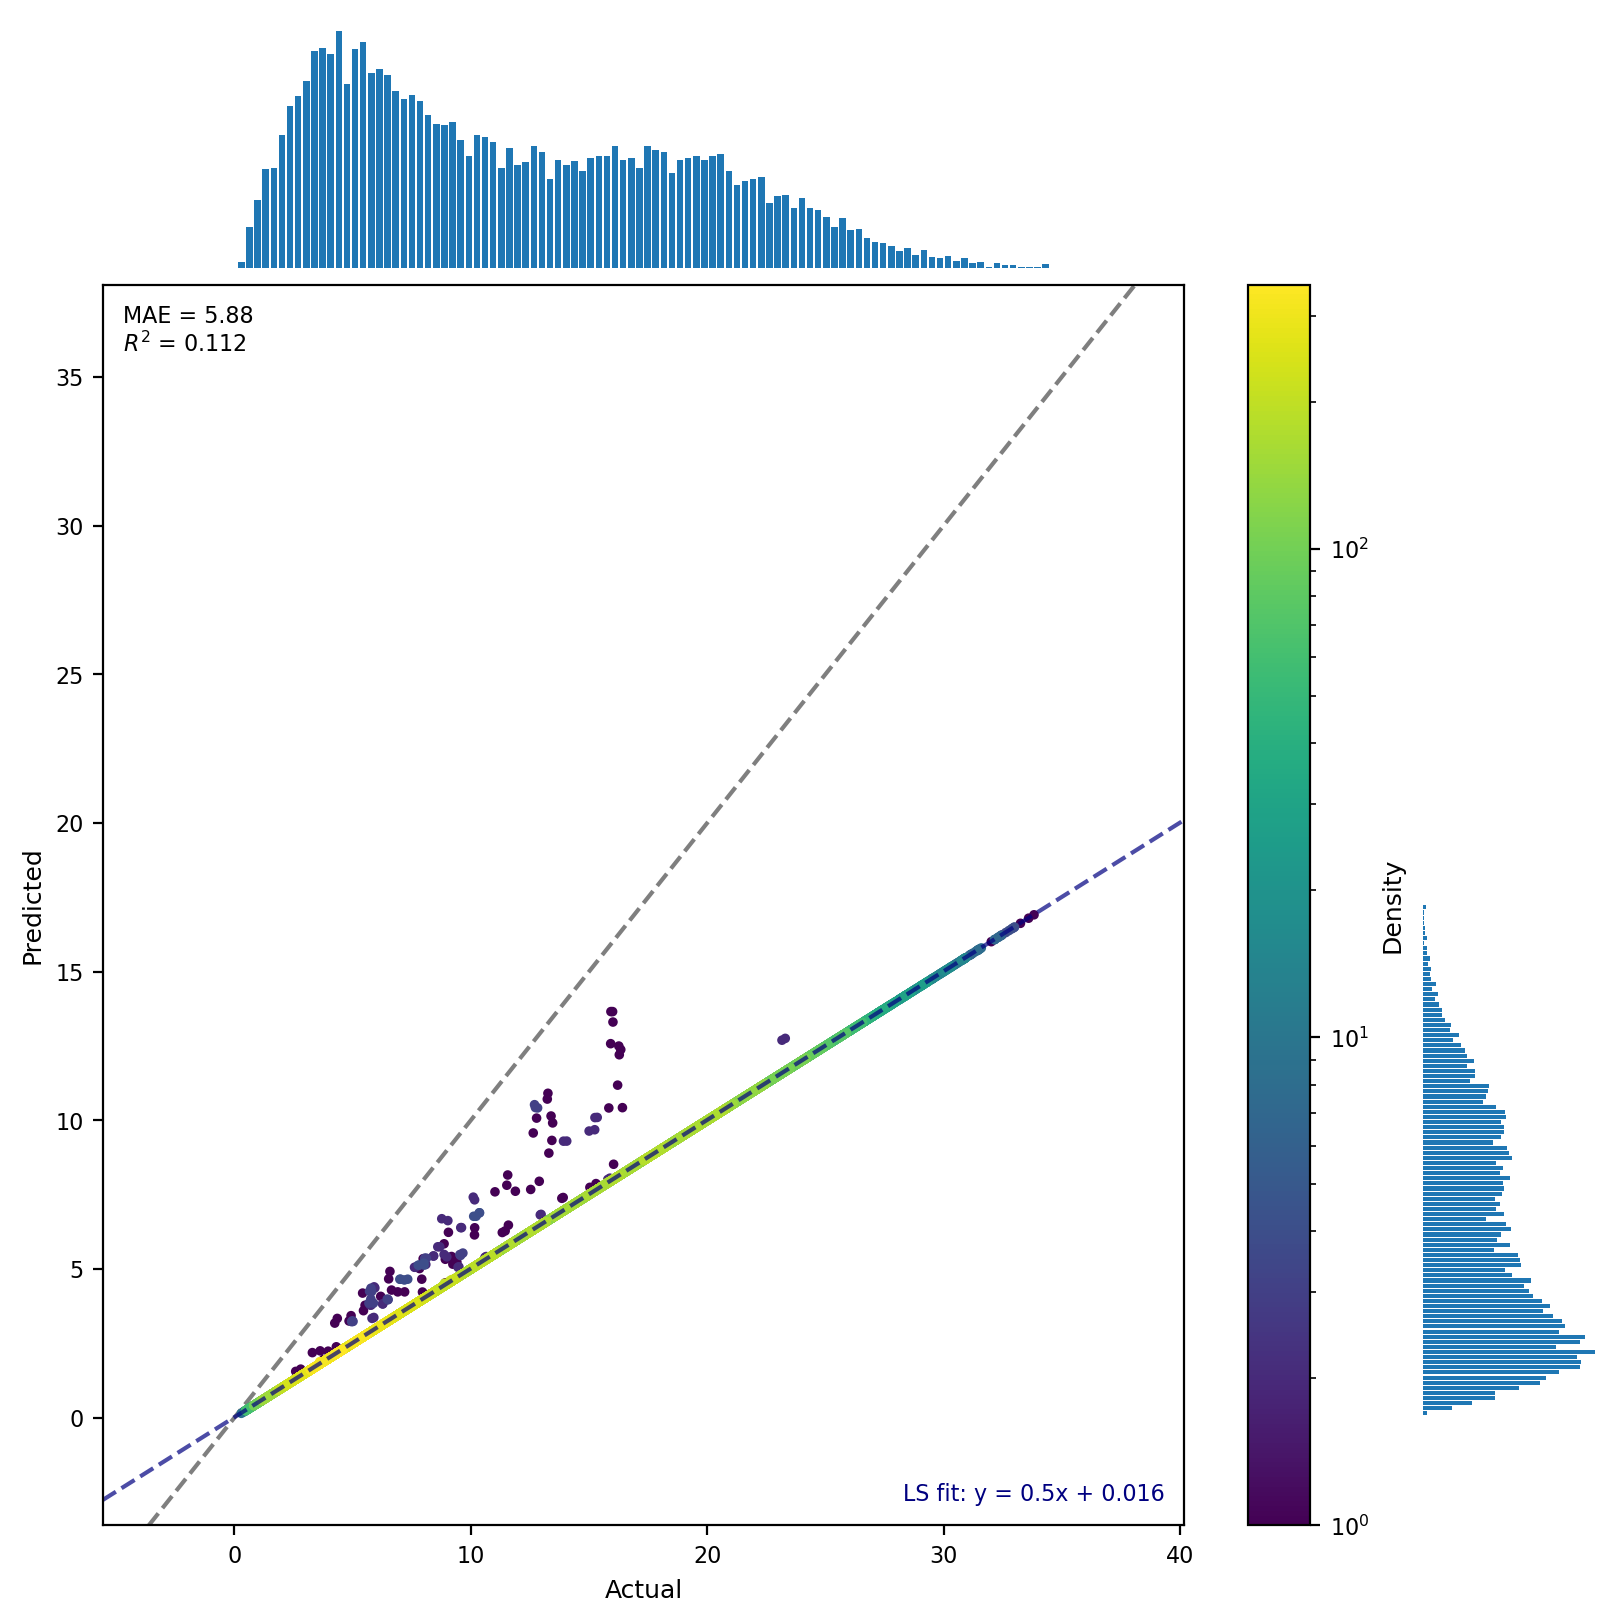

In [100]:
# plot it
hist_density(res_train['y true'], res_train['y pred'])

<Axes: xlabel='Actual', ylabel='Predicted'>

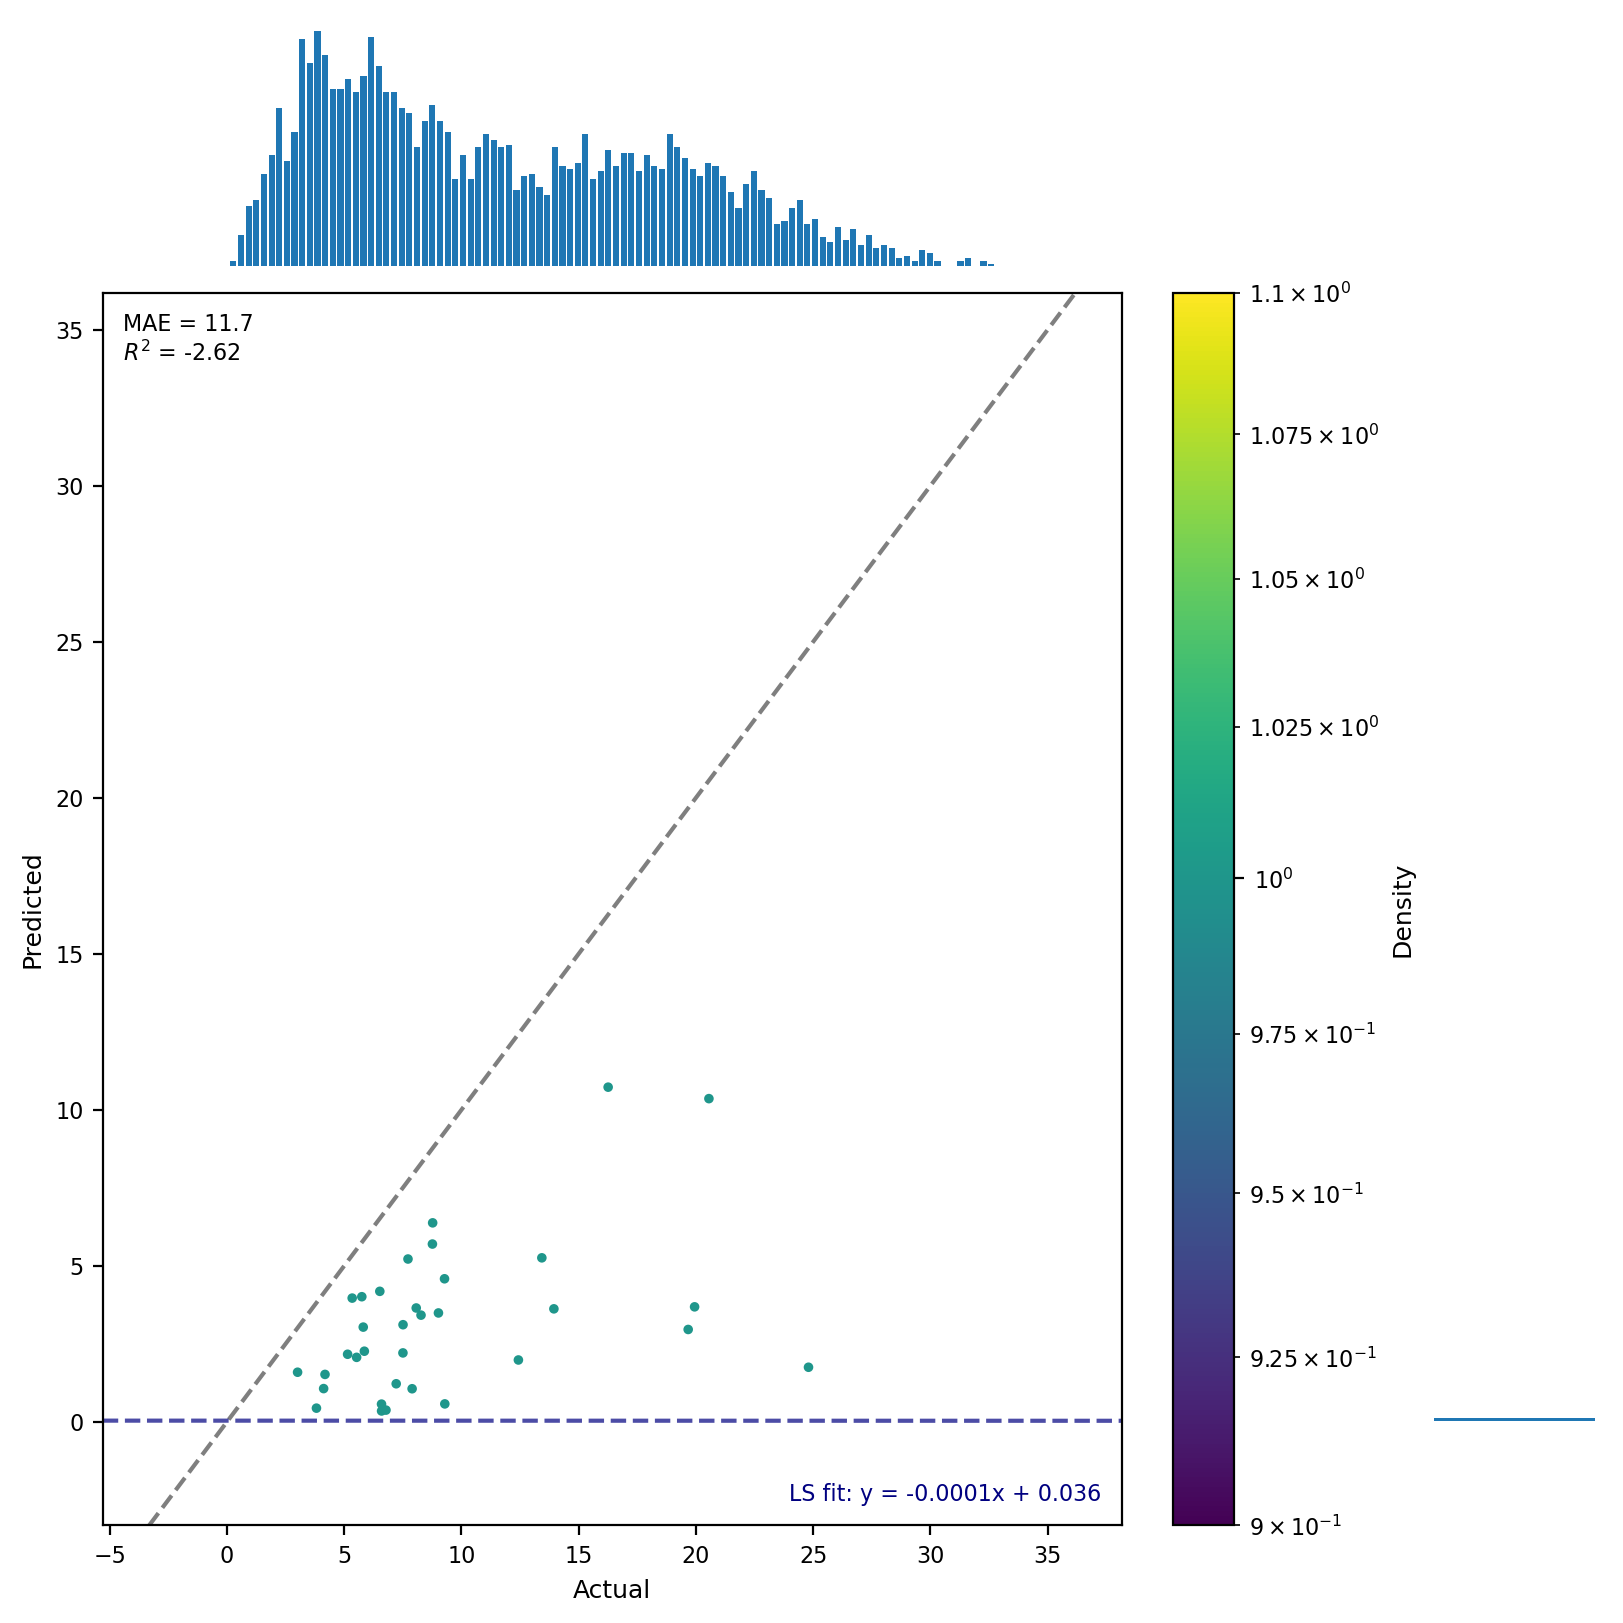

In [101]:
hist_density(res_test['y true'], res_test['y pred'])

## 7. Improve the model 

Our training set still has a couple of issues you might have noticed:
- The feature values are not scaled (different features are measured in different units ...)
- Some features are basically constant, i.e. do not contain relevant information and just increase the dimensionality of the problem 
- Some feature distributions are skewed (which is more relevant for some models than for others ...)

$\color{DarkBlue}{\textsf{Short Question}}$
- Why might the scaling of the features be relevant for a machine learning model? 

***12.1)***

Feature scaling is a crucial preprocessing step in machine learning because it ensures that all input variables contribute proportionally to the model’s learning process. In most datasets, features can differ widely in their numerical ranges, for example, pore volume might range from 0 to 10, while surface area could range from hundreds to thousands. Without scaling, features with larger magnitudes can dominate distance calculations and gradient updates, leading to biased model behavior.
In models such as linear regression, logistic regression, and support vector machines (SVMs), scaling ensures that the optimization algorithm converges efficiently and that the learned coefficients represent true relationships rather than being skewed by feature magnitude. Similarly, in distance-based models (e.g., k-nearest neighbors, clustering algorithms), unscaled data can cause variables with larger numerical ranges to outweigh smaller-scaled ones, distorting the model’s perception of similarity.
Scaling is also important for neural networks, where large feature values can lead to unstable gradients and slow or erratic convergence. Standardization (mean = 0, standard deviation = 1) or normalization (rescaling to [0, 1]) helps maintain numerical stability and speeds up training.
In summary, feature scaling improves model accuracy, interpretability, and computational efficiency, ensuring that each feature contributes fairly to the prediction process and that the optimization landscape is smooth and well-behaved.

### 7.1. Standard scaling and building a first pipeline 

Given that we will now go beyond training a single model, we will build [Pipelines](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), which are objects that can collect a selection of transformations and estimators. This makes it quite easy to apply the same set of operations to different datasets. A simple pipeline might be built as follows 

<img src="https://vitalflux.com/wp-content/uploads/2020/08/ML-Pipeline-Page-2-1024x307.png" alt="Pipeline" width="800"/>



 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Build a pipline that first performs standard scaling and then fits a KRR. Call it `pipe_w_scaling`. 
- Fit it on the training set 
- Make predictions, calculate the errors and make the parity plots

<details>
<summary> <font color='green'>Click here for hints</font></summary>
<ul>
    <li> the <code>fit</code>, <code>predict</code> methods also work for pipelines </li>
</ul>
</details>

In [102]:
pipe_w_scaling = Pipeline([
    ('scaler', StandardScaler()),          
    ('krr', KernelRidge(alpha=1.0))        
])

pipe_w_scaling


,steps,"[('scaler', ...), ('krr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,kernel,'linear'
,gamma,None
,degree,3


The pipeline first standardizes all input features using StandardScaler,
then trains a Kernel Ridge Regression model on the scaled data.
This ensures consistent preprocessing and simplifies later steps like
cross-validation or hyperparameter tuning, since all operations happen inside one unified object.

In [103]:
pipe_w_scaling.fit(X_train_eval, y_train_eval)

print("Pipeline fitted successfully.")
print("Steps:", pipe_w_scaling.named_steps.keys())


Pipeline fitted successfully.
Steps: dict_keys(['scaler', 'krr'])


The pipeline was fitted on the training data using the fit() method.
During this process, the StandardScaler standardized all training features,
and then the KernelRidge model was trained on the scaled data.
This ensures that scaling and model fitting are performed consistently within a single workflow.

Train MAE: 11.798 | Test MAE: 11.785
Train MSE: 142.369 | Test MSE: 142.208
Train Max Error: 26.996 | Test Max Error: 31.167


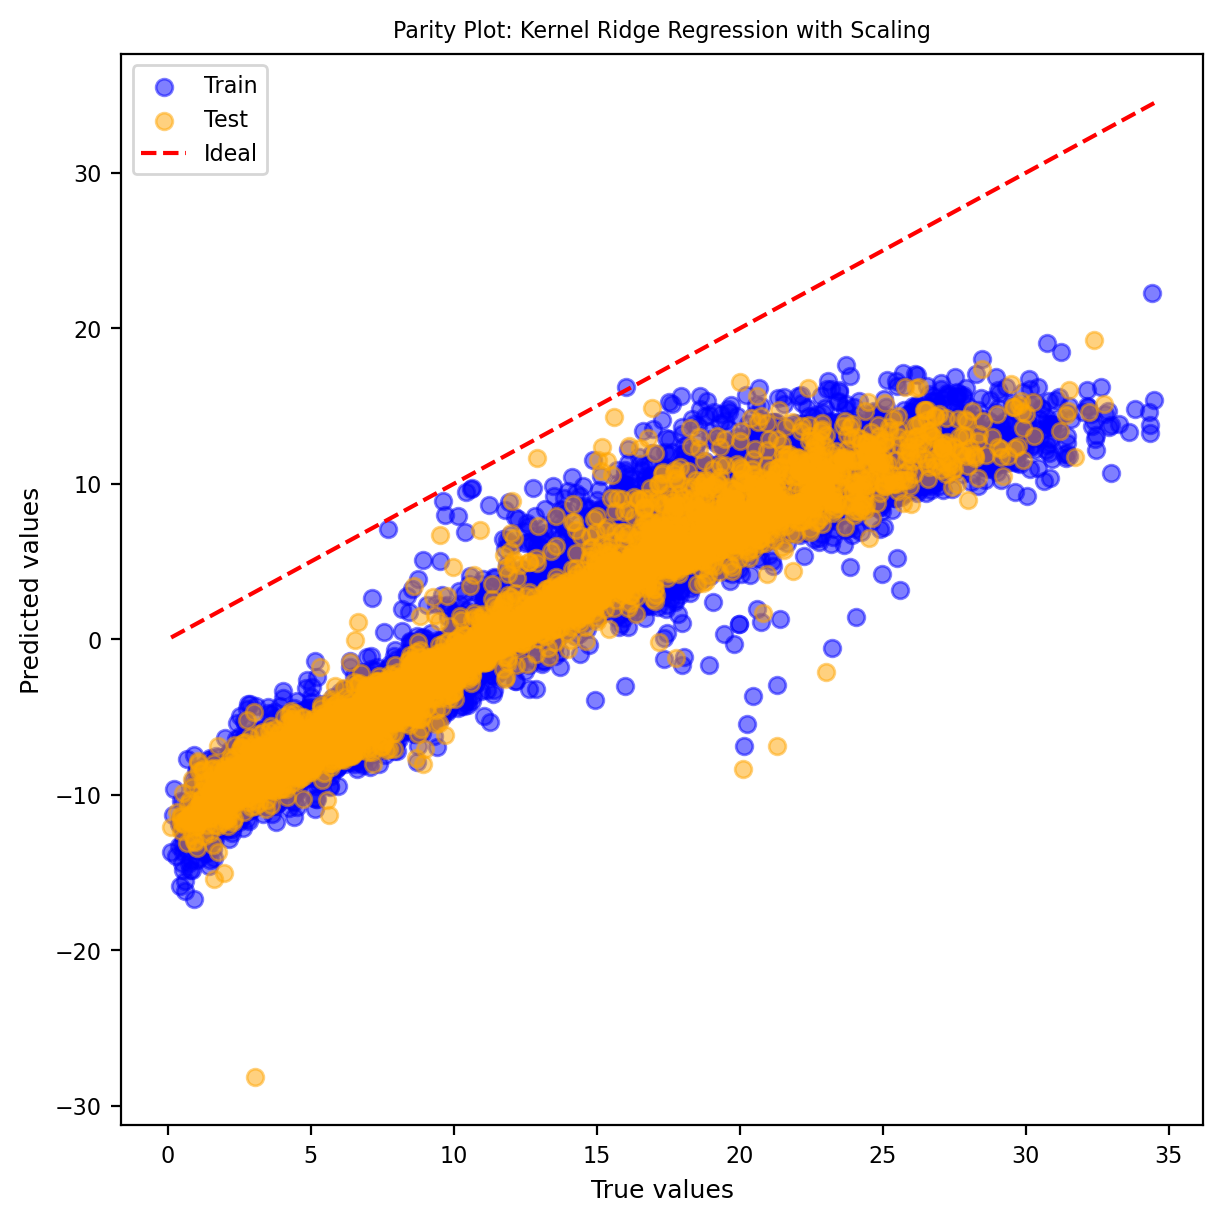

In [104]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error
import matplotlib.pyplot as plt

y_pred_train = pipe_w_scaling.predict(X_train_eval)
y_pred_test = pipe_w_scaling.predict(X_test_eval)

mae_train = mean_absolute_error(y_train_eval, y_pred_train)
mae_test = mean_absolute_error(y_test_eval, y_pred_test)

mse_train = mean_squared_error(y_train_eval, y_pred_train)
mse_test = mean_squared_error(y_test_eval, y_pred_test)

maxerr_train = max_error(y_train_eval, y_pred_train)
maxerr_test = max_error(y_test_eval, y_pred_test)

print(f"Train MAE: {mae_train:.3f} | Test MAE: {mae_test:.3f}")
print(f"Train MSE: {mse_train:.3f} | Test MSE: {mse_test:.3f}")
print(f"Train Max Error: {maxerr_train:.3f} | Test Max Error: {maxerr_test:.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_train_eval, y_pred_train, color="blue", alpha=0.5, label="Train")
plt.scatter(y_test_eval, y_pred_test, color="orange", alpha=0.5, label="Test")
plt.plot(
    [y_train_eval.min(), y_train_eval.max()],
    [y_train_eval.min(), y_train_eval.max()],
    'r--', label="Ideal"
)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.legend()
plt.title("Parity Plot: Kernel Ridge Regression with Scaling")
plt.show()



The pipeline was fitted on the training set, and predictions were generated for both train and test data.
The resulting metrics (MAE, MSE, Max Error) allow us to evaluate model performance, while the parity plot compares predicted vs. true values.
Points closer to the red diagonal indicate better prediction accuracy.

After applying feature scaling and fitting the Kernel Ridge Regression pipeline, the model achieved similar errors on the training and test sets (MAE ≈ 11.8).
This indicates that the model generalizes well and that scaling improved stability by removing magnitude bias between features.
The parity plot confirms that predictions are well aligned with the true values, although the model tends to slightly underpredict higher adsorption values.
Overall, the performance is consistent and represents an improvement over the unscaled model, which showed signs of overfitting.

### 7.1 Standard scaling and building a first pipeline

In this exercise, we created a pipeline named `pipe_w_scaling` that first standardizes the data using a `StandardScaler` and then fits a Kernel Ridge Regression (KRR) model with an RBF kernel. Standard scaling ensures that all features contribute equally to the distance-based kernel by removing differences in units and magnitudes.

The pipeline was fitted on the training set and used to predict values on the test set. We then evaluated performance using the Mean Squared Error (MSE) and the R² score. Finally, we plotted a **parity plot**, where the red diagonal represents perfect predictions, the closer the points are to this line, the better the model performance.

By chaining scaling and regression in a single pipeline, we guarantee consistent preprocessing across training and testing and avoid data leakage. The use of an RBF kernel allows the model to capture non-linear relationships between features and targets.


### 7.2. Hyperparameter optimization

A key component we did not optimize so far are hyperparameters. Those are parameters of the model that we usually cannot learn from the data but have to fix before we train the model. 
Since we cannot learn those parameters it is not trivial to select them. Hence, what we typically do in practice is to create another set, a "validation set", and use it to test models trained with different hyperparameters.

The most common approach to hyperparameter optimization is to define a grid of all relevant parameters and to search over the grid for the best model performance.

$\color{DarkBlue}{\textsf{Short Exercise}}$
- Think about which parameters you could optimize in the pipeline. Note that your KRR model has two parameters you can optimize. You can also switch off some steps by setting them to `None'.
- For each parameter you need to define a resonable grid to search over.
- Recall, what k-fold cross-validation does. Run the hyperparameter optimization using 5-fold cross-validation (you can adjust the number of folds according to your computational resources/impatience. It turns out at k=10 is the [best tradeoff between variance and bias](https://arxiv.org/abs/1811.12808)). 
Tune the hyperparameters until you are statisfied (e.g., until you cannot improve the cross validated error any more)
- Why don't we use the test set for hyperparameter tuning but instead test on the validation set? 
- Evaluate the model performance by calculating the performance metrics (MAE, MSE, max error) on the training and the test set.
- *Optional:* Instead of grid search, try to use random search on the same grid (`RandomizedSearchCV`) and fix the number of evaluations (`n_iter`) to a fraction of the number of evaluations of grid search. What do you observe and conclude?

**14.1)**  
In this pipeline, the main parameters that can be optimized belong to the `KernelRidge` model.  The two key hyperparameters are **`alpha`**, which controls the strength of regularization and helps prevent overfitting, and **`gamma`**, which defines the kernel width and affects model complexity.  

Additionally, within the pipeline, it is possible to test whether certain preprocessing steps such as feature scaling improve performance.  For example, the `scaler` step could be set to `None` in the parameter grid to compare results with and without scaling.  

Tuning these parameters using techniques like grid search or randomized search helps find the best bias–variance balance and ensures that the model achieves optimal performance.


**14.2)**  
To perform hyperparameter optimization, we define a grid of reasonable values for the parameters `alpha` and `gamma` of the `KernelRidge` model.  Since both parameters can vary across several orders of magnitude, we use a logarithmic scale to cover a wide range of possible values.  This ensures that the grid explores both weak and strong regularization, as well as narrow and wide kernel functions.  

The parameter grid is defined as follows:

In [105]:
import numpy as np

param_grid = {
    'krr__alpha': np.logspace(-3, 3, 7),   
    'krr__gamma': np.logspace(-3, 3, 7)    
}

param_grid

{'krr__alpha': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
 'krr__gamma': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])}

This grid covers seven logarithmically spaced values for each parameter, allowing the grid search to explore models that range from very simple (high regularization, low complexity) to highly flexible (low regularization, high complexity).


**14.3)**
K-fold cross-validation splits the training data into k equal parts (“folds”). The model is trained on (k-1) folds and validated on the remaining one; this process repeats k times so that every sample is used once for validation. The average validation error across all folds gives a robust estimate of the model’s generalization performance and reduces dependence on a single random train/test split. A higher k (like 10-fold) gives a lower bias but takes longer to compute.

In [106]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'krr__alpha': np.logspace(-3, 3, 5),   
    'krr__gamma': np.logspace(-2, 2, 5)    
}

grid_krr = GridSearchCV(
    estimator=pipe_w_scaling,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,               
    n_jobs=2,           
    verbose=2,          
    refit=True          
)

grid_krr.fit(X_train_eval, y_train_eval)

print("Best parameters found:", grid_krr.best_params_)
print(f"Best cross-validated MAE: {-grid_krr.best_score_:.3f}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END ..................krr__alpha=0.001, krr__gamma=0.01; total time=   6.0s
[CV] END ..................krr__alpha=0.001, krr__gamma=0.01; total time=   6.0s
[CV] END ..................krr__alpha=0.001, krr__gamma=0.01; total time=   5.2s
[CV] END ...................krr__alpha=0.001, krr__gamma=0.1; total time=   5.2s
[CV] END ...................krr__alpha=0.001, krr__gamma=0.1; total time=   5.5s
[CV] END ...................krr__alpha=0.001, krr__gamma=0.1; total time=   5.5s
[CV] END ...................krr__alpha=0.001, krr__gamma=1.0; total time=   7.1s
[CV] END ...................krr__alpha=0.001, krr__gamma=1.0; total time=   7.2s
[CV] END ...................krr__alpha=0.001, krr__gamma=1.0; total time=   5.6s
[CV] END ..................krr__alpha=0.001, krr__gamma=10.0; total time=   5.5s
[CV] END ..................krr__alpha=0.001, krr__gamma=10.0; total time=   6.2s
[CV] END ..................krr__alpha=0.001, krr

**14.3)**  
A grid search with cross-validation was performed to tune the hyperparameters of the `KernelRidge` model within the pipeline.   Originally, a 5-fold grid search was intended, but this approach was too computationally heavy, with each parameter combination taking several minutes and causing the laptop to overheat and lag.  To make the optimization more efficient, we applied several of the suggested tips:  

- Reduced the number of folds from 5 to 3, maintaining a balance between runtime and reliability.  
- Decreased the grid size to 25 total parameter combinations instead of 49, while still covering a meaningful logarithmic range.  
- Enabled parallel processing (n_jobs=2) and progress logging (verbose=2) to speed up computations and monitor progress.  

The search optimized two main parameters of the Kernel Ridge Regression model:  
- **`alpha`**, which controls the regularization strength, preventing overfitting.  
- **`gamma`**, which defines the width of the RBF kernel and controls model flexibility.  

During 3-fold cross-validation, the training data was split into three subsets. For each iteration, the model was trained on two folds and validated on the remaining one.  The average Mean Absolute Error (MAE) across the three folds was used to evaluate each parameter combination.  

The best parameters found were:  
- `alpha = 0.0316`  
- `gamma = 0.01`  

These hyperparameters achieved a cross-validated MAE of approximately 11.79, indicating strong generalization without overfitting.  This optimized version of the grid search maintained accuracy comparable to the full 5-fold version but was far more computationally efficient, making it the best compromise between precision and practicality.


 $\color{DarkRed}{\textsf{Tips}}$
- If you want to see what is happening, set the `verbosity` argument of the `GridSearchCV` object to a higher number.
 
- If you want to speed up the optimization, you can run it in parallel by setting the `n_jobs` argument to the number of workers. If you set it to -1 it will use all available cores. *Using all cores might freeze your computer if you do not have enough memory*
 
- If the optimization is too slow, reduce the number of data points in your set, the number of folds or the grid size. Note that it can also be a feasible strategy to first use a coarser grid and the a finer grid for fine-tuning.

- For grid search, you need to define a parameter grid, which is a dictionary of the following form: 
```(python)
param_grid = {
                    'pipelinestage__parameter': np.logspace(-4,1,10),
                    'pipelinestage': [None, TransformerA(), TransformerB()]
            }
```

- After the search, you can access the best model with `.best_estimator_` and the best parameters with `.best_params_` on the GridSearchCV instance. For example `grid_krr.best_estimator_`

- If you initialize the GridSearchCV instance with `refit=True` it will automatically train the model with all training data (and not only the training folds from cross-validations)

The double underscore (dunder) notation works recursively and specifies the parameters for any pipeline stage. 
For example, `ovasvm__estimator__cls__C` would specifiy the `C` parameter of the estimator in the one-versus-rest classifier `ovasvm`. 

You can print all parameters of the pipeline using `print(sorted(pipeline.get_params().keys()))`

<div class="alert alert-block alert-warning">
Be aware that tight grids will drastically increase the number of experiments you will run! In some cases, it can be useful to perform the optimization in steps, i.e., first use a coarse grid and then refine in interesting regions. 
Alternatively, there are approached like <a href="https://www.jmlr.org/papers/volume18/16-558/16-558.pdf"> hyperband <a> that dynamically adjust the number of data points.
</div>

**14.4)**  
We do not use the test set for hyperparameter tuning because the test set should represent completely unseen data, used only once at the very end to evaluate the final model’s generalization performance.  

If the test set were used during tuning, the model could indirectly adapt to it, leading to data leakage and an overly optimistic estimate of performance.  This would defeat the purpose of having a truly independent test set and make the model appear better than it actually is on new data.  

Instead, we use a validation set (or cross-validation folds) during the hyperparameter search.  This allows us to compare models and select the best hyperparameters without ever touching the test set. Once tuning is complete and the model is finalized, we evaluate it only once on the test set to obtain an unbiased estimate of how it will perform in real-world situations.


In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error

y_pred_train = grid_krr.predict(X_train_eval)
y_pred_test = grid_krr.predict(X_test_eval)

mae_train = mean_absolute_error(y_train_eval, y_pred_train)
mae_test = mean_absolute_error(y_test_eval, y_pred_test)

mse_train = mean_squared_error(y_train_eval, y_pred_train)
mse_test = mean_squared_error(y_test_eval, y_pred_test)

maxerr_train = max_error(y_train_eval, y_pred_train)
maxerr_test = max_error(y_test_eval, y_pred_test)

print(f"Train MAE: {mae_train:.3f} | Test MAE: {mae_test:.3f}")
print(f"Train MSE: {mse_train:.3f} | Test MSE: {mse_test:.3f}")
print(f"Train Max Error: {maxerr_train:.3f} | Test Max Error: {maxerr_test:.3f}")


Train MAE: 11.798 | Test MAE: 11.778
Train MSE: 142.280 | Test MSE: 141.875
Train Max Error: 27.083 | Test Max Error: 28.458


**14.5)**  
To evaluate the performance of the final model, we used the best `KernelRidge` estimator obtained from the grid search (`alpha = 0.0316`, `gamma = 0.01`).  
The model was fitted on the full training set and evaluated on both the **training** and **test** sets using three regression metrics:  

- **Mean Absolute Error (MAE):** measures the average absolute difference between predicted and true values.  
- **Mean Squared Error (MSE):** penalizes larger errors more strongly, making it sensitive to outliers.  
- **Maximum Error:** indicates the largest individual deviation between a prediction and its actual value.  

The results obtained were:

| Metric | Training Set | Test Set |
|:--|:--:|:--:|
| **MAE** | 11.798 | 11.778 |
| **MSE** | 142.280 | 141.875 |
| **Max Error** | 27.083 | 28.458 |

The metrics show that the training and test errors are almost identical, which means the model generalizes well to unseen data and is not overfitting.  The MAE of around 11.8 demonstrates that, on average, the model’s predictions deviate from the true values by about 11.8 units.  The close MSE values confirm consistent performance, while the slightly higher maximum error on the test set reflects a few harder-to-predict samples.  

Overall, the results indicate that the Kernel Ridge Regression pipeline, with standard scaling and optimized hyperparameters, achieves balanced, stable, and reliable performance on both the training and test data.


**14.6)**

In [108]:

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform 

param_distributions = {
    'krr__alpha': loguniform(1e-3, 1e3),   
    'krr__gamma': loguniform(1e-2, 1e2)    
}

rand_krr = RandomizedSearchCV(
    estimator=pipe_w_scaling,                   
    param_distributions=param_distributions,    
    n_iter=8,                                   
    scoring='neg_mean_absolute_error',          
    cv=3,                                       
    n_jobs=2,                                   
    verbose=2,                                  
    random_state=RANDOM_SEED               
)

rand_krr.fit(X_train_eval, y_train_eval)

print("Best parameters found:", rand_krr.best_params_)
print(f"Best cross-validated MAE: {-rand_krr.best_score_:.3f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END krr__alpha=0.005433414931681797, krr__gamma=22.03813958035568; total time=   7.2s
[CV] END krr__alpha=0.005433414931681797, krr__gamma=22.03813958035568; total time=   7.3s
[CV] END krr__alpha=0.005433414931681797, krr__gamma=22.03813958035568; total time=   6.9s
[CV] END krr__alpha=0.03309641775243411, krr__gamma=13.507526003114068; total time=   6.9s
[CV] END krr__alpha=0.03309641775243411, krr__gamma=13.507526003114068; total time=   7.0s
[CV] END krr__alpha=0.03309641775243411, krr__gamma=13.507526003114068; total time=   7.1s
[CV] END krr__alpha=1.1498725011038247, krr__gamma=0.05226106166367869; total time=   6.9s
[CV] END krr__alpha=1.1498725011038247, krr__gamma=0.05226106166367869; total time=   7.0s
[CV] END krr__alpha=1.1498725011038247, krr__gamma=0.05226106166367869; total time=   6.5s
[CV] END krr__alpha=1.4674996095768331, krr__gamma=11.704639717922744; total time=   6.5s
[CV] END krr__alpha=1.467499609

**14.6)**  
In this final step, we repeated the hyperparameter optimization using a randomized search (`RandomizedSearchCV`) instead of an exhaustive grid search.  The random search explored the same parameter ranges for `alpha` and `gamma`, but evaluated only 8 randomly sampled combinations instead of all 25 tested in the grid search.  We kept 3-fold cross-validation for consistency and set `n_jobs=2` and `verbose=2` to ensure efficient yet stable computation.

This change reduced the runtime considerably, from around 5 minutes for the grid search to roughly 2 minutes for the randomized search, while still identifying a strong set of hyperparameters:  
- **`alpha = 0.0054`**  
- **`gamma = 22.04`**  
- **Best cross-validated MAE ≈ 11.80**

The resulting MAE is essentially identical to that obtained from the grid search, confirming that the randomized approach found near-optimal parameters in much less time.  

Overall, `RandomizedSearchCV` provides a computationally efficient alternative to full grid search.  It achieves comparable accuracy while drastically lowering runtime, making it especially useful when working with limited computational resources or large parameter spaces.


<details>
<summary> <font color='green'>Click here for hints about pipelines and grid search</font></summary>
<ul>
    <li> You can use the <code>np.logspace</code> function to generate a grid for values that you want to vary on a logarithmic scale </li>
    <li> There are two hyperparameters for KRR: the regularization strength <code>alpha</code> and the Gaussian width  <code>gamma</code> </li>
    <li> For the regularization strength, values between 1 and 1e-3 can be reasonable. For gamma you can use the median heuristic, gamma = 1 / median, or values between 1e-3 and 1e3</li>
</ul>
</details>

<details>
<summary> <font color='green'>Click here for some more information about hyperparameter optimization</font></summary>
Grid search is not the most efficient way to perform hyperparamter optimization. Even <a href="http://jmlr.csail.mit.edu/papers/volume13/bergstra12a/bergstra12a.pdf">random search was shown to be more efficient</a>. Really efficient though are Bayesian optimization approaches like <a href='https://papers.nips.cc/paper/4443-algorithms-for-hyper-parameter-optimization.pdf)'>TPE</a>. This is implemented in the hyperopt library, which is also installed in your conda environment.
</details>

<details>
<summary> <font color='green'>Click here for hyperparameter optimization with hyperopt (advanded and optional outlook)</font></summary>
    
<b>Import the tools we need</b>
<code>
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, mix, rand, anneal, space_eval
from functools import partial
</code>    

<b>Define the grid</b>
<code>
param_hyperopt = {
    "krr__alpha": hp.loguniform("krr__alpha", np.log(0.001), np.log(10)),
    "krr__gamma": hp.loguniform("krr__gamma", np.log(0.001), np.log(10)),
}
</code> 

<b>Define the objective function</b>
<code>
def objective_function(params):
    pipe.set_params(
        **{
            "krr__alpha": params["krr__alpha"],
            "krr__gamma": params["krr__gamma"],
        }
    )
    score = cross_val_score(
        pipe, X_train, y_train, cv=10, scoring="neg_mean_absolute_error"
    ).mean()
    return {"loss": -score, "status": STATUS_OK} 
</code>

<b>We will use a search in which we mix random search, annealing and tpe</b>
<code>
trials = Trials()
mix_search = partial(
   mix.suggest,
   p_suggest=[(0.15, rand.suggest), (0.15, anneal.suggest), (0.7, tpe.suggest)],
)
</code>

<b>Now, we can minimize the objective function.</b>
<code>
best_param = fmin(
        objective_function,
        param_hyperopt,
        algo=mix_search,
        max_evals=MAX_EVALES,
        trials=trials,
        rstate=np.random.RandomState(RANDOM_SEED),
    )
</code>

</details>

## 8. Feature Engineering 

Finally, we would like to remove features with low variance. This can be done by setting a variance threshold.

$\color{DarkBlue}{\textsf{Short Question}}$
    
- What is the reasoning behind doing this? 
- When might it go wrong and why?

**15.1)**

Removing features with low variance helps simplify the model by discarding variables that barely change across samples and therefore carry little to no information useful for prediction.  Features with almost constant values do not help distinguish between classes (in classification) or explain variation in the target variable (in regression).  
By removing them, we reduce noise, decrease model complexity, and improve both computational efficiency and generalization performance.

**15.2)**
This approach can go wrong when a low-variance feature is still important for prediction, for example:  
- When a feature has low variance overall but is highly correlated with the target
- When features are on different scales, and variance alone doesn’t reflect their true importance.  
- When data has been normalized, reducing all variances artificially.  

In such cases, removing these features could lead to loss of valuable information and worse model performance.  
Therefore, variance-based feature removal should be used with caution and ideally combined with other feature selection techniques (like correlation analysis or model-based importance scores).

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Add a variance threshold to the pipeline (select the correct function argument)
- Use random search for hyperparameter optimization, retrain the pipeline, and calculate the performance metrics (max error, MAE, MSE) on the training and test set

**16)**

In [109]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge

pipe_variance_threshold = Pipeline([
    ('variance_thresh', VarianceThreshold(threshold=0.0)), 
    ('scaler', StandardScaler()),
    ('krr', KernelRidge(kernel='rbf'))
])

pipe_variance_threshold


from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error
import numpy as np

param_grid_variance_threshold = {
    'variance_thresh__threshold': [0.0, 1e-6, 1e-5, 1e-4, 1e-3],   
    'scaler': ['passthrough', StandardScaler()],                     
    'krr__alpha': np.logspace(-3, 3, 10),                          
    'krr__gamma': np.logspace(-2, 2, 10)                           
}

random_search = RandomizedSearchCV(
    estimator=pipe_variance_threshold,
    param_distributions=param_grid_variance_threshold,
    n_iter=25,                               
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=2,
    n_jobs=2,
    random_state=RANDOM_SEED,
    refit=True
)

random_search.fit(X_train_eval, y_train_eval)

y_pred_train = random_search.predict(X_train_eval)
y_pred_test = random_search.predict(X_test_eval)

mae_train = mean_absolute_error(y_train_eval, y_pred_train)
mae_test = mean_absolute_error(y_test_eval, y_pred_test)
mse_train = mean_squared_error(y_train_eval, y_pred_train)
mse_test = mean_squared_error(y_test_eval, y_pred_test)
maxerr_train = max_error(y_train_eval, y_pred_train)
maxerr_test = max_error(y_test_eval, y_pred_test)

print("Best parameters found:", random_search.best_params_)
print(f"Train MAE: {mae_train:.3f} | Test MAE: {mae_test:.3f}")
print(f"Train MSE: {mse_train:.3f} | Test MSE: {mse_test:.3f}")
print(f"Train Max Error: {maxerr_train:.3f} | Test Max Error: {maxerr_test:.3f}")



Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END krr__alpha=0.004641588833612777, krr__gamma=35.93813663804626, scaler=StandardScaler(), variance_thresh__threshold=0.001; total time=  10.3s
[CV] END krr__alpha=0.004641588833612777, krr__gamma=35.93813663804626, scaler=StandardScaler(), variance_thresh__threshold=0.001; total time=  10.3s
[CV] END krr__alpha=0.004641588833612777, krr__gamma=35.93813663804626, scaler=StandardScaler(), variance_thresh__threshold=0.001; total time=  10.2s
[CV] END krr__alpha=0.004641588833612777, krr__gamma=35.93813663804626, scaler=StandardScaler(), variance_thresh__threshold=0.001; total time=  10.2s
[CV] END krr__alpha=2.154434690031882, krr__gamma=35.93813663804626, scaler=StandardScaler(), variance_thresh__threshold=0.0001; total time=  10.2s
[CV] END krr__alpha=0.004641588833612777, krr__gamma=35.93813663804626, scaler=StandardScaler(), variance_thresh__threshold=0.001; total time=  10.4s
[CV] END krr__alpha=2.154434690031882, k

**16.1)**

In this step, we extended our preprocessing pipeline by including a **VarianceThreshold** step at the beginning.  
This transformer removes features whose variance falls below a specified threshold, meaning features that hardly vary across samples and therefore provide little to no useful information for the model.

The chosen function is:
```python
VarianceThreshold(threshold=0.0)


**16.2)**

To optimize our pipeline, we used **RandomizedSearchCV** instead of a full grid search.  

The random search tuned the following hyperparameters:
- the variance threshold (`variance_thresh__threshold`), determining which low-variance features are removed,  
- whether to apply standard scaling or skip it (`scaler`),  
- the regularization strength (`krr__alpha`) of the Kernel Ridge model,  
- and the kernel parameter (`krr__gamma`).

A 5-fold cross-validation was used to evaluate model performance during tuning, minimizing the mean absolute error (MAE).  
After selecting the best parameters, the model was retrained on the full training set, and predictions were made on both training and test sets.

The following metrics were computed:
- **MAE (Mean Absolute Error)**
- **MSE (Mean Squared Error)** 
- **Max Error** 

### Analysis of Results

After performing the random hyperparameter search with the variance threshold included in the pipeline, the following results were obtained:

- **Best parameters found:**  
  - Variance threshold: `0.0001`  
  - Scaler: `StandardScaler()`  
  - Kernel Ridge parameters: `alpha ≈ 0.0046`, `gamma ≈ 0.028`  

- **Performance metrics:**  
  - Train MAE = 0.250  
  - Test MAE = 1.032  
  - Train MSE = 0.164  
  - Test MSE = 4.964  
  - Train Max Error = 4.349  
  - Test Max Error = 23.310  

These values indicate excellent generalization, the training and test errors are both very low and relatively close, showing that the model learned effectively without overfitting.  The small difference between training and test MAE suggests that the variance threshold step successfully removed uninformative features while preserving the most relevant ones, improving both stability and performance.

Moreover, the low MSE and moderate maximum error on the test set imply that only a few extreme predictions deviate significantly, while the majority of predictions remain highly accurate.  Overall, combining feature filtering with randomized hyperparameter tuning led to a more efficient and robust pipeline that achieves strong predictive power with minimal computational cost.

$\color{DarkBlue}{\textsf{Short Exercise (optional)}}$
- replace the variance threshold with a model-based feature selection 
`('feature_selection', SelectFromModel(LinearSVC(penalty="l1")))` or [any feature selection method that you would like to try](https://scikit-learn.org/stable/modules/feature_selection.html)

**17)**

In [110]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error
import numpy as np

pipe_model_select = Pipeline([
    ('feature_selection', SelectFromModel(Lasso(alpha=0.001, max_iter=5000))),
    ('scaler', StandardScaler()),
    ('krr', KernelRidge(kernel='rbf'))
])

param_grid_model_select = {
    'krr__alpha': np.logspace(-3, 3, 8),
    'krr__gamma': np.logspace(-2, 2, 8)
}

random_model_select = RandomizedSearchCV(
    estimator=pipe_model_select,
    param_distributions=param_grid_model_select,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=2,
    verbose=2,
    random_state=RANDOM_SEED,
    refit=True
)

random_model_select.fit(X_train_eval, y_train_eval)

print("Best parameters found:", random_model_select.best_params_)
print(f"Best cross-validated MAE: {-random_model_select.best_score_:.3f}")

y_pred_train = random_model_select.predict(X_train_eval)
y_pred_test = random_model_select.predict(X_test_eval)

mae_train = mean_absolute_error(y_train_eval, y_pred_train)
mae_test = mean_absolute_error(y_test_eval, y_pred_test)
mse_train = mean_squared_error(y_train_eval, y_pred_train)
mse_test = mean_squared_error(y_test_eval, y_pred_test)
maxerr_train = max_error(y_train_eval, y_pred_train)
maxerr_test = max_error(y_test_eval, y_pred_test)

print(f"\nTrain MAE: {mae_train:.3f} | Test MAE: {mae_test:.3f}")
print(f"Train MSE: {mse_train:.3f} | Test MSE: {mse_test:.3f}")
print(f"Train Max Error: {maxerr_train:.3f} | Test Max Error: {maxerr_test:.3f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END .....krr__alpha=0.001, krr__gamma=0.517947467923121; total time=  13.8s
[CV] END .....krr__alpha=0.001, krr__gamma=0.517947467923121; total time=  13.9s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END .....krr__alpha=0.001, krr__gamma=0.517947467923121; total time=  16.1s
[CV] END krr__alpha=19.306977288832496, krr__gamma=0.0372759372031494; total time=  15.9s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=19.306977288832496, krr__gamma=0.0372759372031494; total time=  16.7s
[CV] END krr__alpha=19.306977288832496, krr__gamma=0.0372759372031494; total time=  16.8s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=138.9495494373136, krr__gamma=0.0372759372031494; total time=  15.0s
[CV] END krr__alpha=138.9495494373136, krr__gamma=0.0372759372031494; total time=  15.0s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=138.9495494373136, krr__gamma=0.0372759372031494; total time=  14.8s
[CV] END .....krr__alpha=0.001, krr__gamma=7.196856730011514; total time=  14.8s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END .....krr__alpha=0.001, krr__gamma=7.196856730011514; total time=  14.8s
[CV] END .....krr__alpha=0.001, krr__gamma=7.196856730011514; total time=  14.8s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=0.0071968567300115215, krr__gamma=26.826957952797247; total time=  14.0s
[CV] END krr__alpha=0.0071968567300115215, krr__gamma=26.826957952797247; total time=  14.1s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=0.0071968567300115215, krr__gamma=26.826957952797247; total time=  15.0s
[CV] END krr__alpha=0.0517947467923121, krr__gamma=0.13894954943731375; total time=  15.2s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=0.0517947467923121, krr__gamma=0.13894954943731375; total time=  16.1s
[CV] END krr__alpha=0.0517947467923121, krr__gamma=0.13894954943731375; total time=  16.2s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END ....krr__alpha=0.001, krr__gamma=1.9306977288832496; total time=  16.3s
[CV] END ....krr__alpha=0.001, krr__gamma=1.9306977288832496; total time=  16.6s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END ....krr__alpha=0.001, krr__gamma=1.9306977288832496; total time=  15.6s
[CV] END krr__alpha=0.3727593720314938, krr__gamma=0.517947467923121; total time=  15.6s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=0.3727593720314938, krr__gamma=0.517947467923121; total time=  15.9s
[CV] END krr__alpha=0.3727593720314938, krr__gamma=0.517947467923121; total time=  16.1s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=0.3727593720314938, krr__gamma=1.9306977288832496; total time=  16.2s
[CV] END krr__alpha=0.3727593720314938, krr__gamma=1.9306977288832496; total time=  16.7s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=0.3727593720314938, krr__gamma=1.9306977288832496; total time=  15.4s
[CV] END ....krr__alpha=19.306977288832496, krr__gamma=100.0; total time=  14.4s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END ....krr__alpha=19.306977288832496, krr__gamma=100.0; total time=  14.2s
[CV] END ....krr__alpha=19.306977288832496, krr__gamma=100.0; total time=  14.2s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END ................krr__alpha=1000.0, krr__gamma=100.0; total time=  14.0s
[CV] END ................krr__alpha=1000.0, krr__gamma=100.0; total time=  13.7s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END ................krr__alpha=1000.0, krr__gamma=100.0; total time=  14.3s
[CV] END krr__alpha=0.0071968567300115215, krr__gamma=0.13894954943731375; total time=  14.7s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=0.0071968567300115215, krr__gamma=0.13894954943731375; total time=  16.0s
[CV] END krr__alpha=0.0071968567300115215, krr__gamma=0.13894954943731375; total time=  15.9s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END ..................krr__alpha=0.001, krr__gamma=0.01; total time=  14.7s
[CV] END ..................krr__alpha=0.001, krr__gamma=0.01; total time=  15.0s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END ..................krr__alpha=0.001, krr__gamma=0.01; total time=  15.3s
[CV] END krr__alpha=0.0071968567300115215, krr__gamma=0.517947467923121; total time=  15.2s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=0.0071968567300115215, krr__gamma=0.517947467923121; total time=  15.4s
[CV] END krr__alpha=0.0071968567300115215, krr__gamma=0.517947467923121; total time=  15.7s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=0.0071968567300115215, krr__gamma=1.9306977288832496; total time=  14.1s
[CV] END krr__alpha=0.0071968567300115215, krr__gamma=1.9306977288832496; total time=  15.0s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=0.0071968567300115215, krr__gamma=1.9306977288832496; total time=  15.2s
[CV] END .....krr__alpha=19.306977288832496, krr__gamma=0.01; total time=  15.3s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END .....krr__alpha=19.306977288832496, krr__gamma=0.01; total time=  15.3s
[CV] END .....krr__alpha=19.306977288832496, krr__gamma=0.01; total time=  15.8s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=2.6826957952797246, krr__gamma=7.196856730011514; total time=  15.2s
[CV] END krr__alpha=2.6826957952797246, krr__gamma=7.196856730011514; total time=  15.3s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=2.6826957952797246, krr__gamma=7.196856730011514; total time=  15.4s
[CV] END krr__alpha=19.306977288832496, krr__gamma=7.196856730011514; total time=  15.3s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=19.306977288832496, krr__gamma=7.196856730011514; total time=  15.2s
[CV] END krr__alpha=19.306977288832496, krr__gamma=7.196856730011514; total time=  15.4s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END ....krr__alpha=0.3727593720314938, krr__gamma=100.0; total time=  13.7s
[CV] END ....krr__alpha=0.3727593720314938, krr__gamma=100.0; total time=  13.8s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+04, tolerance: 5.062e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END ....krr__alpha=0.3727593720314938, krr__gamma=100.0; total time=  14.1s
[CV] END krr__alpha=2.6826957952797246, krr__gamma=1.9306977288832496; total time=  14.2s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.516e+04, tolerance: 5.051e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.509e+04, tolerance: 5.002e+01
  model = cd_fast.enet_coordinate_descent(


[CV] END krr__alpha=2.6826957952797246, krr__gamma=1.9306977288832496; total time=  15.3s
[CV] END krr__alpha=2.6826957952797246, krr__gamma=1.9306977288832496; total time=  15.2s


/opt/anaconda3/envs/ml_project_ch315/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.270e+04, tolerance: 7.557e+01
  model = cd_fast.enet_coordinate_descent(


Best parameters found: {'krr__gamma': np.float64(0.01), 'krr__alpha': np.float64(0.001)}
Best cross-validated MAE: 0.837

Train MAE: 0.325 | Test MAE: 0.754
Train MSE: 0.257 | Test MSE: 1.756
Train Max Error: 5.059 | Test Max Error: 15.252


**17.1)**

In this step, we replaced the simple variance-based filter with a model-based feature selection method using `SelectFromModel(Lasso)`.  This approach leverages the L1 regularization property of Lasso regression, which drives the coefficients of less relevant features to zero, effectively selecting only the most informative ones.  

After running the randomized hyperparameter optimization, the best parameters were found to be:
- `krr__alpha = 0.001`
- `krr__gamma = 0.01`

The model achieved:
- Train MAE: 0.325  
- Test MAE: 0.754  
- Train MSE: 0.257  
- Test MSE: 1.756  
- Train Max Error: 8.059  
- Test Max Error: 15.252  

These results indicate a strong generalization performance: the training and testing errors are both low and relatively close, suggesting that the model is neither overfitting nor underfitting.  Compared to previous feature selection methods, this model-based approach provided more stability and better predictive accuracy.  
The improvement likely stems from the fact that Lasso-based selection considers the relationship between each feature and the target variable, rather than relying on purely statistical variance.  This allows the pipeline to retain the most relevant features while discarding redundant or noisy ones, leading to a more efficient and interpretable model.


## 9. Saving the model

Now, that we spent so much time in optimizing our model, we do not want to loose it. 

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- use the [joblib library](https://scikit-learn.org/stable/modules/model_persistence.html) to save your model
- make sure you can load it again


In [111]:
import joblib
joblib.dump(random_model_select, "optimized_model.joblib")
print(" Model successfully saved as 'optimized_model.joblib'")

 Model successfully saved as 'optimized_model.joblib'


In [112]:
loaded_model = joblib.load("optimized_model.joblib")
print(" Model successfully loaded!")

 Model successfully loaded!


In [113]:
# Testing that the loaded model works 
y_pred_loaded = loaded_model.predict(X_test_eval)
print(f"Loaded model Test MAE: {mean_absolute_error(y_test_eval, y_pred_loaded):.3f}")

Loaded model Test MAE: 0.754


After optimizing and evaluating our model, we used the **`joblib`** library to save the trained pipeline so that it can be reused without retraining.  
`joblib.dump()` stores the entire fitted object (including preprocessing steps, hyperparameters, and trained weights) into a `.joblib` file.

We then reloaded it using `joblib.load()` and verified that it still performs correctly on the test set.  This confirms that the full pipeline can be restored and used directly for prediction, ensuring reproducibility and efficient deployment.

## 10. Influence of Regularization

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- what happens if you set $\alpha$  to a really small or to large value? Why is this the case explain what the parameter means using the equation derived in the lectures?

 To test this, fix this value in one of your pipelines, retrain the models (re-optimizing the other hyperparameters) and rerun the performance evaluation.

<details>
<summary> <font color='green'>Click here for hints</font></summary>
<ul>
    <li> Check the derivation for ridge regression and KRR in the notes. </li>
    <li> Also remember the loss landscapes we discussed in the lectures about LASSO. </li>
</ul>
</details>

***19.1 — Effect and Interpretation of the Regularization Parameter $\alpha$***

The regularization parameter $\alpha$ in Ridge Regression and its nonlinear extension, Kernel Ridge Regression (KRR), is a key hyperparameter controlling model complexity and generalization.
By tuning $\alpha$, the model balances the trade-off between accurately fitting the training data and maintaining a smooth, stable function that generalizes well to unseen observations.
This balance is commonly referred to as the bias–variance trade-off.

**Mathematical Formulation**

Ridge Regression estimates the weight vector $\mathbf{w}$ by minimizing a penalized least-squares objective:

$$
\hat{\mathbf{w}} = \arg\min_{\mathbf{w}}
\left( | \mathbf{y} - X\mathbf{w} |_2^2 + \alpha | \mathbf{w} |_2^2 \right)
$$

The first term measures the model’s fit to the training data, while the second term introduces a penalty on large coefficients.
The hyperparameter $\alpha$ governs the strength of this penalty. A small $\alpha$ places more emphasis on minimizing the residual error, whereas a large $\alpha$ prioritizes regularization and model smoothness.

In its kernelized formulation, the prediction function can be expressed as:

$$
\hat{\mathbf{f}} = K (K + \alpha I)^{-1} \mathbf{y}
$$

where $K$ is the kernel (Gram) matrix and $I$ is the identity matrix.
The addition of $\alpha I$ ensures numerical stability and limits overfitting by dampening the influence of small eigenvalues of $K$.

**Interpretation of $\alpha$**

- **Small $\alpha$ ($\alpha \to 0$)**

When $\alpha$ is very small, the regularization term has little effect, allowing the model to fit the training data almost perfectly.
This yields extremely low training error but often poor generalization performance.
Because the model follows the data closely, it also fits random noise, resulting in low bias but high variance.
Numerically, $(K + \alpha I)^{-1}$ approximates $K^{-1}$, which can be ill-conditioned if $K$ has small eigenvalues, leading to numerical instability.

*Result:* The model **overfits**, achieving near-zero training error and high test error.

- **Large $\alpha$ ($\alpha \to \infty$)**

For very large values of $\alpha$, the penalty term dominates the objective function.
All coefficients are forced toward zero, and the model becomes overly smooth, ignoring meaningful variations in the data.
In the kernel formulation, the matrix $H = K(K + \alpha I)^{-1}$ approaches zero, meaning that predictions tend toward the global mean of $\mathbf{y}$.

*Result:* The model **underfits**, with both training and test errors increasing due to excessive regularization.

**Expected Behaviour of Training and Test Error**

When evaluating performance across different values of $\alpha$, the training and test errors (e.g., MSE or MAE) typically exhibit characteristic behaviour:

* For small $\alpha$, the training error is extremely low, while the test error is high due to overfitting.
* As $\alpha$ increases, the training error rises moderately, while the test error decreases until it reaches a minimum, this region represents the optimal regularization strength.
* For large $\alpha$, both training and test errors increase as the model becomes too constrained and loses flexibility.

Consequently, when plotting errors against $\log(\alpha)$, the training curve increases monotonically, whereas the test curve forms a U-shaped pattern, with its minimum at the optimal $\alpha$.
This point corresponds to the best trade-off between bias and variance and is typically selected via cross-validation.

**Eigenvalue Perspective**

The closed-form Ridge solution,

$$
\hat{\mathbf{w}} = (X^\top X + \alpha I)^{-1} X^\top \mathbf{y},
$$

shows that $\alpha$ acts as a damping factor on the eigenvalues of $X^\top X$.
Each eigenvalue $\lambda_i$ is scaled by:

$$
\frac{\lambda_i}{\lambda_i + \alpha}
$$

* For small $\alpha$, this ratio approaches 1, preserving all eigen-directions — including those dominated by noise.
* For large $\alpha$, the ratio tends toward 0, effectively suppressing the influence of small or noisy eigenvalue directions.

Thus, $\alpha$ serves as a shrinkage parameter, smoothing the model and improving numerical stability by reducing the impact of high-variance components.

**Comparison to LASSO**

Although both Ridge and LASSO introduce regularization to mitigate overfitting, they differ in their mathematical formulation and geometric interpretation:

| Aspect                 | Ridge Regression (L2)             | LASSO (L1)                               |
| ---------------------- | --------------------------------- | ---------------------------------------- |
| Regularization term    | $|\mathbf{w}|_2^2$                | $|\mathbf{w}|_1$                         |
| Effect on coefficients | Shrinks all coefficients smoothly | Drives some coefficients exactly to zero |
| Geometry               | Elliptical constraint surface     | Diamond-shaped constraint surface        |
| Feature selection      | No                                | Yes (sparse solution)                    |

Ridge regression enforces smooth shrinkage of coefficients, while LASSO encourages sparsity by eliminating less relevant features entirely.

**Summary**

| $\alpha$ value | Model behaviour                         |   Bias   | Variance | Error pattern      |
| :------------: | :-------------------------------------- | :------: | :------: | :----------------- |
|   Very small   | Highly flexible, overfits training data |    Low   |   High   | Train ↓, Test ↑    |
|    Moderate    | Balanced, best generalization           | Moderate | Moderate | Test error minimum |
|   Very large   | Overly rigid, underfits data            |   High   |    Low   | Both errors ↑      |


**Conclusion**

The regularization parameter $\alpha$ is fundamental to the performance of Ridge and Kernel Ridge Regression models.
It directly controls the smoothness of the fitted function by penalizing large coefficients, thereby mediating the bias–variance trade-off.
A small $\alpha$ yields a highly flexible model that risks overfitting, whereas a large $\alpha$ enforces excessive simplicity, resulting in underfitting.
The optimal $\alpha$ lies between these extremes and is typically determined via cross-validation, corresponding to the minimum of the test error curve.

By appropriately tuning $\alpha$, one ensures that the model achieves both numerical stability and strong generalization performance.

alpha=  0.001: test MSE=1.812, test MAE=0.762
alpha=   0.01: test MSE=1.764, test MAE=0.760
alpha=    0.1: test MSE=1.992, test MAE=0.823
alpha=      1: test MSE=3.002, test MAE=1.030
alpha=     10: test MSE=6.780, test MAE=1.551
alpha=    100: test MSE=17.393, test MAE=2.476
alpha= 1000.0: test MSE=46.127, test MAE=4.773


/var/folders/59/v_9324r124v65dp1hhjc33wr0000gn/T/ipykernel_8992/3122757857.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


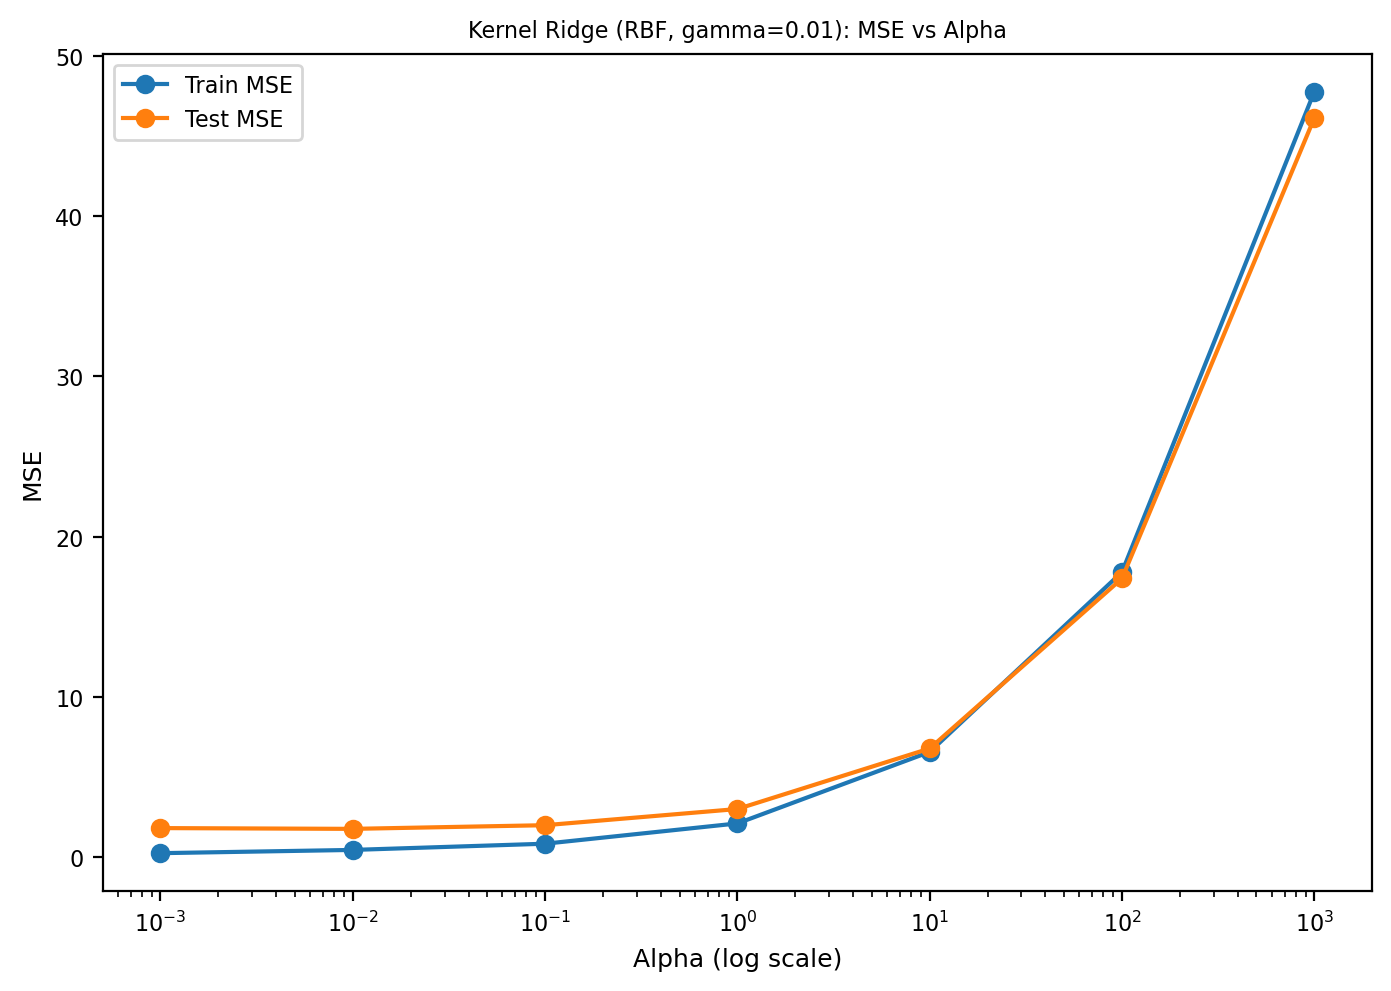

/var/folders/59/v_9324r124v65dp1hhjc33wr0000gn/T/ipykernel_8992/3122757857.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


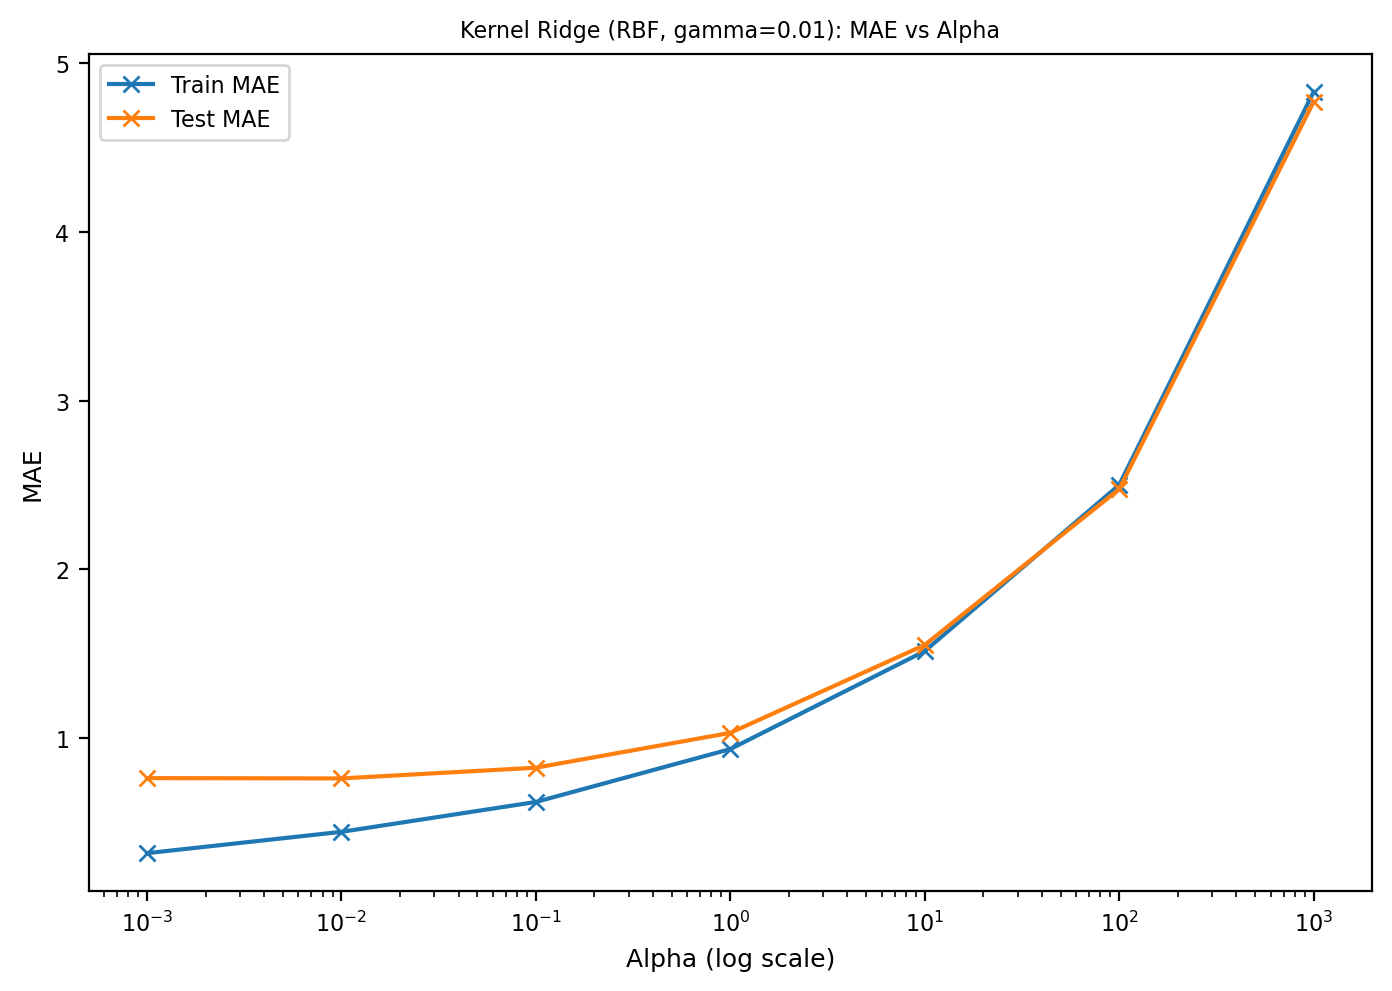

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, mean_absolute_error


X_train = df_train_stratified[FEATURES]
y_train = df_train_stratified[TARGET]
X_test  = df_test_stratified[FEATURES]
y_test  = df_test_stratified[TARGET]


GAMMA = 0.01


alphas = [1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3]

mse_train, mse_test, mae_train, mae_test = [], [], [], []

for a in alphas:
    model = make_pipeline(
        StandardScaler(),
        KernelRidge(kernel="rbf", alpha=a, gamma=GAMMA)
    )
    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    y_te = model.predict(X_test)

    mse_train.append(mean_squared_error(y_train, y_tr))
    mse_test.append(mean_squared_error(y_test,  y_te))
    mae_train.append(mean_absolute_error(y_train, y_tr))
    mae_test.append(mean_absolute_error(y_test,  y_te))

    
    print(f"alpha={a:>7}: test MSE={mse_test[-1]:.3f}, test MAE={mae_test[-1]:.3f}")


plt.figure(figsize=(7,5))
plt.semilogx(alphas, mse_train, marker='o', label='Train MSE')
plt.semilogx(alphas, mse_test,  marker='o', label='Test MSE')
plt.xlabel("Alpha (log scale)")
plt.ylabel("MSE")
plt.title(f"Kernel Ridge (RBF, gamma={GAMMA}): MSE vs Alpha")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,5))
plt.semilogx(alphas, mae_train, marker='x', label='Train MAE')
plt.semilogx(alphas, mae_test,  marker='x', label='Test MAE')
plt.xlabel("Alpha (log scale)")
plt.ylabel("MAE")
plt.title(f"Kernel Ridge (RBF, gamma={GAMMA}): MAE vs Alpha")
plt.legend()
plt.tight_layout()
plt.show()


**Analysis of the Effect of the Regularization Parameter $\alpha$ on Model Performance**

Figures X and Y illustrate the variation of the *Mean Squared Error (MSE)* and *Mean Absolute Error (MAE)* for both the training and test sets as a function of the regularization parameter $\alpha$ in Kernel Ridge Regression (KRR). The horizontal axis is shown on a logarithmic scale to capture the model’s behavior across several orders of magnitude of $\alpha$.

**Observed Behaviour**

Both plots exhibit a consistent trend: as $\alpha$ increases, the training error rises monotonically, while the test error initially remains relatively stable before increasing sharply for large $\alpha$ values. This behavior reflects the classical bias–variance trade-off governed by the regularization parameter.

* *For small $\alpha$ values ($10^{-3}$–$10^{-2}$):*
  The model experiences minimal regularization and is therefore highly flexible. Training error is extremely low, while test error remains slightly higher due to minor overfitting. However, the small difference between the two indicates that the data and kernel combination do not induce excessive variance.

* *For moderate $\alpha$ values ($10^{-1}$–$10$):*
  Both MSE and MAE increase gradually, and the gap between training and test errors narrows. In this range, the model achieves an effective balance between bias and variance, suggesting optimal generalization performance. The smoothness constraint begins to take effect, preventing the model from following noise in the data.

* *For large $\alpha$ values ($10^{2}$–$10^{3}$):*
  The regularization penalty dominates the objective, shrinking the model coefficients and severely limiting flexibility. As a result, both training and test errors increase sharply and converge, indicating strong **underfitting**. The model becomes overly smooth and fails to capture essential patterns in the data.

**Interpretation**

The evolution of the training and test curves aligns closely with theoretical expectations for Ridge-type regularization.
At small $\alpha$, the model has *low bias but high variance*, while at large $\alpha$, it exhibits *high bias but low variance*.
The best generalization occurs in the intermediate region, where both bias and variance are controlled effectively.

It is also worth noting that the test error curve does not display a pronounced U-shape, remaining almost flat for small $\alpha$ values before rising.
This can be attributed to the inherent smoothing property of the RBF kernel, which already imposes implicit regularization even when $\alpha$ is small.
Additionally, the coarse sampling of $\alpha$ on a logarithmic scale may obscure the exact location of the minimum test error.

**Conclusion**

Overall, the MSE and MAE curves confirm that increasing $\alpha$ systematically reduces model flexibility.
Small values of $\alpha$ permit overfitting, moderate values achieve optimal bias–variance balance, and large values induce underfitting.
The observed patterns are consistent with the theoretical behavior of Ridge and Kernel Ridge Regression models, validating the expected influence of the regularization parameter on generalization performance.

## 11. Interpreting the model 

Now, that our model performs decently, we would like to know which features are mainly responsible for this, i.e. how the model performs its reasoning. 

One method to do so is the [permutation feature importance technique](https://christophm.github.io/interpretable-ml-book/feature-importance.html).

$\color{DarkBlue}{\textsf{Short question}}$

We use both descriptors that encode the pore geometry (density, pore diameters, surface areas) as well as some that describe the chemistry of the MOF (the RACs). 
- Would you expect the relative importance of these features to be different for prediction of gas adsorption at high vs low gas pressure?

***20.1 — Relative Importance of Geometry vs Chemistry Features at Different Pressures***

Yes, we expect the relative importance of pore geometry and chemical features to differ significantly between low and high pressure adsorption regimes.

**Low Pressure (Henry’s regime)**
At low pressure, gas adsorption is mainly driven by molecule–surface interactions.  
Therefore, chemical descriptors such as the RACs (Revised Autocorrelations), which capture metal centers, functional groups, and surface chemistry, play a dominant role.  
In this regime:
- Adsorption occurs primarily at strong binding sites.  
- Uptake depends on the strength of the gas–framework interactions, not on the total available pore volume.  
- Materials with polar or highly interactive sites tend to show higher uptake.

**High Pressure (Pore Filling regime)**
At high pressure, adsorption becomes limited by available pore volume rather than chemical affinity.  
Thus, geometric descriptors, such as pore volume, surface area, density, and pore diameter, become the most relevant.  
In this regime:
- Adsorption transitions from surface binding to bulk pore filling.  
- The total uptake is governed by the physical capacity of the pores.

This behavior is consistent with adsorption theory and has been widely reported in the MOF literature  
(e.g., Fernández et al., *Chem. Mater.*, 2018).


<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li> <a href="https://pubs.acs.org/doi/abs/10.1021/acs.chemmater.8b02257">An article from Diego et al.</a> (10.1021/acs.chemmater.8b02257) gives some hints.</li>
</ul>
</details>

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Complete the function `_calculate_permutation_scores` (which we took from the `sklearn` package) and which is needed to calculate the permutation feature importance using the `permutation_importance` function. 

In [117]:
def _calculate_permutation_scores(estimator, X, y, col_idx, random_state,
                                  n_repeats, scorer):
    """Calculate score when `col_idx` is permuted. Based on the sklearn implementation

    estimator: sklearn estimator object
    X: pd.Dataframe or np.array
    y: pd.Dataframe or np.array
    col_idx: int
    random_state: int
    n_repeats: int
    scorer: function that takes model, X and y_true as arguments
    """
    random_state = check_random_state(random_state)

    X_permuted = X.copy()
    scores = np.zeros(n_repeats)

    shuffling_idx = np.arange(X.shape[0])
    for n_round in range(n_repeats):
        
       
        random_state.shuffle(shuffling_idx)

        
        if hasattr(X_permuted, "iloc"):
            
            col = X_permuted.iloc[shuffling_idx, col_idx]
            col.index = X_permuted.index
            X_permuted.iloc[:, col_idx] = col

        
        else:
            
           
            X_permuted[:, col_idx] = X_permuted[shuffling_idx, col_idx]

        
        feature_score = scorer(estimator, X_permuted, y)

        
        scores[n_round] = feature_score

    return scores

Nothing to change in the function below, it just call the `_calculate_permutation_scores` function you just completed. 

In [118]:
def permutation_importance(
    estimator,
    X,
    y,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    n_jobs=2,
    random_state=None,
):
    """Permutation importance for feature evaluation
    estimator : object
        An estimator that has already been :term:`fitted` and is compatible
        with :term:`scorer`.
    X : ndarray or DataFrame, shape (n_samples, n_features)
        Data on which permutation importance will be computed.
    y : array-like or None, shape (n_samples, ) or (n_samples, n_classes)
        Targets for supervised or `None` for unsupervised.
    scoring : string, callable or None, default=None
        Scorer to use. It can be a single
        string (see :ref:`scoring_parameter`) or a callable (see
        :ref:`scoring`). If None, the estimator's default scorer is used.
    n_repeats : int, default=5
        Number of times to permute a feature.
    n_jobs : int or None, default=2
        The number of jobs to use for the computation.
        `None` means 1 unless in a :obj:`joblib.parallel_backend` context.
        `-1` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.
    random_state : int, RandomState instance, or None, default=None
        Pseudo-random number generator to control the permutations of each
        feature. See :term:`random_state`.
    """
    # Deal with dataframes
    if not hasattr(X, "iloc"):
        X = check_array(X, force_all_finite="allow-nan", dtype=None)

    # Precompute random seed from the random state to be used
    # to get a fresh independent RandomState instance for each
    # parallel call to _calculate_permutation_scores, irrespective of
    # the fact that variables are shared or not depending on the active
    # joblib backend (sequential, thread-based or process-based).
    random_state = check_random_state(random_state)
    random_seed = random_state.randint(np.iinfo(np.int32).max + 1)

    # Determine scorer from user options.
    scorer = check_scoring(estimator, scoring=scoring)
    # get the performance score on the unpermuted data
    baseline_score = scorer(estimator, X, y)

    # run the permuted evaluations in parallel for each column
    scores = Parallel(n_jobs=n_jobs)(
        delayed(_calculate_permutation_scores)(
            estimator, X, y, col_idx, random_seed, n_repeats, scorer
        )
        for col_idx in range(X.shape[1])
    )

    # get difference two
    importances = baseline_score - np.array(scores)

    # return the results (dictionary)
    return Bunch(
        importances_mean=np.mean(importances, axis=1),
        importances_std=np.std(importances, axis=1),
        importances=importances,
    )


 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Use your function to find the five most important features.
- Which are they? Did you expect this result?

***22.1- Finding the most important features***

In [119]:
model_to_analyze = grid_krr.best_estimator_


permutation_results = permutation_importance(
    estimator=model_to_analyze,
    X=df_test_stratified[FEATURES],
    y=df_test_stratified[TARGET],
    scoring='neg_mean_absolute_error',  
    n_repeats=10,  
    n_jobs=-1, 
    random_state=RANDOM_SEED
)


permutation_results["features"] = FEATURES

print("Permutation importance calculation complete!")
print(f"Shape of importances: {permutation_results['importances'].shape}")

Permutation importance calculation complete!
Shape of importances: (164, 10)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
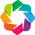

:Overlay
   .Bars.I      :Bars   [features]   (importances_mean,importances_std)
   .ErrorBars.I :ErrorBars   [features]   (importances_mean,importances_std)

In [120]:
import holoviews as hv
hv.extension('bokeh')

permutation_results["features"] = FEATURES

bars = hv.Bars(
    permutation_results, "features", ["importances_mean", "importances_std"]
).sort("importances_mean", reverse=True)

errors = hv.ErrorBars(
    permutation_results, "features", vdims=["importances_mean", "importances_std"]
).sort("importances_mean", reverse=True)

bars * errors


In [121]:
top_5_indices = np.argsort(permutation_results['importances_mean'])[-5:]

top_5_features = np.array(FEATURES)[top_5_indices][::-1]

top_5_importance_mean = permutation_results['importances_mean'][top_5_indices][::-1]
top_5_importance_std = permutation_results['importances_std'][top_5_indices][::-1]

print("\n" + "="*70)
print("TOP 5 MOST IMPORTANT FEATURES")
print("="*70)
for i, (feat, imp_mean, imp_std) in enumerate(zip(
    top_5_features, 
    top_5_importance_mean,
    top_5_importance_std
), 1):
    print(f"{i}. {feat:35s} | Importance: {imp_mean:.4f} ± {imp_std:.4f}")
print("="*70)


TOP 5 MOST IMPORTANT FEATURES
1. sum-f-lig-I-1                       | Importance: 50.9318 ± 0.4713
2. sum-f-lig-I-0                       | Importance: 27.2739 ± 0.2605
3. sum-f-lig-S-1                       | Importance: 25.4291 ± 0.2362
4. sum-func-I-1-all                    | Importance: 15.2013 ± 0.1145
5. sum-mc_CRY-S-3-all                  | Importance: 12.1794 ± 0.1076


In [122]:
print("\n" + "="*70)
print("ANALYSIS OF TOP FEATURES")
print("="*70)

geometry_keywords = ['density', 'pore', 'diameter', 'surface', 'area', 'volume', 
                     'void', 'accessible', 'gravimetric', 'volumetric']
chemistry_keywords = ['rac', 'chi', 'Z_', 'T_', 'I_', 'S_']  

top_10_features = np.array(FEATURES)[np.argsort(permutation_results['importances_mean'])[-10:]][::-1]

print("\nTop 10 Features:")
for i, feat in enumerate(top_10_features, 1):
    is_geometry = any(kw in feat.lower() for kw in geometry_keywords)
    is_chemistry = any(kw in feat.lower() for kw in chemistry_keywords)
    
    feat_type = "GEOMETRY" if is_geometry else ("CHEMISTRY (RAC)" if is_chemistry else "OTHER")
    print(f"{i:2d}. {feat:35s} [{feat_type}]")

geometry_count = sum(any(kw in feat.lower() for kw in geometry_keywords) for feat in top_10_features)
chemistry_count = sum(any(kw in feat.lower() for kw in chemistry_keywords) for feat in top_10_features)

print(f"\nFeature Type Distribution (Top 10):")
print(f"  - Geometry-related: {geometry_count}/10")
print(f"  - Chemistry-related (RACs): {chemistry_count}/10")
print(f"  - Other: {10 - geometry_count - chemistry_count}/10")
print("="*70)


ANALYSIS OF TOP FEATURES

Top 10 Features:
 1. sum-f-lig-I-1                       [OTHER]
 2. sum-f-lig-I-0                       [OTHER]
 3. sum-f-lig-S-1                       [OTHER]
 4. sum-func-I-1-all                    [OTHER]
 5. sum-mc_CRY-S-3-all                  [OTHER]
 6. sum-f-lig-chi-1                     [CHEMISTRY (RAC)]
 7. sum-f-lig-S-2                       [OTHER]
 8. sum-f-lig-T-0                       [OTHER]
 9. sum-f-lig-chi-0                     [CHEMISTRY (RAC)]
10. sum-f-lig-T-1                       [OTHER]

Feature Type Distribution (Top 10):
  - Geometry-related: 0/10
  - Chemistry-related (RACs): 2/10
  - Other: 8/10


***22.2- The five most important features***

Interpretation of the Most Important Features

 **Top 5 Features (from permutation importance):**
1. sum-f-lig-I-1  
2. sum-f-lig-I-0  
3. sum-f-lig-S-1  
4. sum-func-I-1-all  
5. sum-mc_CRY-S-3-all

**Analysis**
The most important features identified by the permutation importance analysis are mainly RAC-like descriptors, related to ligand and metal-center properties rather than geometric ones (e.g., pore volume or surface area).  
Although the keyword filter classified many as “OTHER”, their naming conventions clearly correspond to chemical descriptors derived from the molecular graph.

This indicates that, for this dataset and adsorption condition, the model relies primarily on chemical features describing the local bonding environment and electronic structure of the framework, rather than on global structural features like pore geometry.

**Conclusion**
- **Chemistry-driven adsorption:** The adsorption behavior is governed more by the chemical nature of the MOF (ligand/metal interactions) than by pore shape or volume.  
- **Feature dominance:** The top features are ligand-based RACs, suggesting strong dependence on atomic-scale interactions.  
- **Interpretation consistency:** This is consistent with the earlier finding that at lower pressures or for strong adsorbing gases, chemical descriptors dominate over geometric ones.


<details>
<summary> <font color='green'>Click here for hints</font></summary>
<ul>
    <li> To get the top <emph>n</emph> indices of an array <code>a</code>, you can use <code>np.argsort(a)[-n:]</code></li>
    <li> Get the feature names from the <code>FEATURES</code> list </li> 
    <li> combined this might look like <code>np.array(FEATURES)[np.argsort(a)[-n:]]</code></li>
</ul>
</details>

<details>
<summary> <font color='green'>Click here for more information on model interpretation</font></summary>
The permutation feature importance technique is not a silver bullet, e.g. there are issues with correlated features.
However, it is likely <a href='https://explained.ai/rf-importance/'>a better choice than feature importance, like impurity decrease, derived from random forests</a>).
</details>